### Explo : sectorial and sub-sectorial indicators - all types of indicators 

In [7]:
import pandas as pd
from pathlib import Path

# Définition de votre seuil académique de départ
start_date = pd.to_datetime('2015-03-02')

# ── 1. Chargement de la base GLOBALE (indicators) ──
dir_global = Path("data/indicators")
if dir_global.exists():
    files_global = list(dir_global.glob("*.parquet"))
    df_global = pd.concat([pd.read_parquet(f) for f in files_global], ignore_index=True)
    df_global = df_global.groupby('period').max().reset_index()
    df_global['period'] = pd.to_datetime(df_global['period'])
    df_global = df_global[df_global['period'] >= start_date].sort_values('period')
    print(f"✓ Base GLOBALE chargée : {len(df_global)} jours, de {df_global['period'].min().date()} à {df_global['period'].max().date()}")
else:
    df_global = None
    print("⚠ Dossier ./indicators introuvable.")

# ── 2. Chargement de la base RÉGIONALE (US, France + UK) ──
dir_geo = Path("data/indicators_geo_daily")        # Contains US & France daily files
dir_uk  = Path("data/indicators_geo_UK")     # Contains UK daily files

files_geo = []
if dir_geo.exists():
    files_geo.extend(list(dir_geo.glob("*.parquet")))
else:
    print(f"⚠ Dossier {dir_geo} introuvable.")

if dir_uk.exists():
    files_geo.extend(list(dir_uk.glob("*.parquet")))
else:
    print(f"⚠ Dossier {dir_uk} introuvable.")

if files_geo:
    # Lecture et concaténation de tous les fichiers (US, France, UK)
    df_geo = pd.concat([pd.read_parquet(f) for f in files_geo], ignore_index=True)
    
    # Dédoublonnage / Agrégation propre par (period, region_key)
    df_geo = df_geo.groupby(['period', 'region_key']).max().reset_index()
    df_geo['period'] = pd.to_datetime(df_geo['period'])
    
    # Filtrage temporel
    df_geo = df_geo[df_geo['period'] >= start_date].sort_values(['period', 'region_key'])
    
    print(f"✓ Base RÉGIONALE chargée : {len(df_geo):,} lignes")
    print(f"  Régions détectées : {list(df_geo['region_key'].unique())}")
    print(f"  Période couverte  : de {df_geo['period'].min().date()} à {df_geo['period'].max().date()}")
else:
    df_geo = None
    print("⚠ Aucun fichier parquet trouvé dans les dossiers spécifiés.")

⚠ Dossier ./indicators introuvable.
⚠ Dossier data/indicators_geo_UK introuvable.
✓ Base RÉGIONALE chargée : 12,333 lignes
  Régions détectées : ['France', 'UK', 'US']
  Période couverte  : de 2015-03-02 à 2026-06-19


/tmp/ipykernel_993052/1395699670.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_geo = df_geo.groupby(['period', 'region_key']).max().reset_index()
/tmp/ipykernel_993052/1395699670.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_geo = df_geo.groupby(['period', 'region_key']).max().reset_index()


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

def plot_academic_subsectors_grid(df_geo, sector_name, regions, metric_prefix="att_weight", rolling_window=30, filename="Fig_Subsectors_Grid.pdf"):
    """
    Crée une planche académique lisible.
    - Camaïeu Bleu/Rouge
    - Vrais pourcentages (sans min-max scaling)
    - Espacements optimisés
    - Échelles Y indépendantes (sharey=False) pour ne pas écraser les courbes
    - 🔥 3 graphiques par ligne (col_wrap=3)
    """
    # ==========================================
    # 1. CONFIGURATION ESTHÉTIQUE "LATEX / NBER"
    # ==========================================
    sns.set_theme(style="ticks", context="paper")
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 8,              
        "axes.titlesize": 10,        
        "axes.labelsize": 8,         
        "xtick.labelsize": 7,        
        "ytick.labelsize": 7,        
        "axes.linewidth": 0.6,       
        "xtick.major.width": 0.6,    
        "ytick.major.width": 0.6,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight"
    })

    # ==========================================
    # 2. IDENTIFICATION & PRÉPARATION
    # ==========================================
    prefix = f"{metric_prefix}_{sector_name}"
    cols_to_plot = [c for c in df_geo.columns if c == prefix or c.startswith(prefix + "_")]
    
    if not cols_to_plot:
        print(f"⚠ Aucun sous-secteur trouvé pour '{sector_name}'.")
        return
        
    df_plot = df_geo[df_geo['region_key'].isin(regions)][['period', 'region_key'] + cols_to_plot].copy()
    
    melted = df_plot.melt(
        id_vars=['period', 'region_key'], 
        value_vars=cols_to_plot, 
        var_name='Category', 
        value_name='Raw_Value'
    )
    
    def clean_name(c):
        if c == prefix: return f"{sector_name.upper()} (Total)"
        return c.replace(f"{prefix}_", "").replace("_", " ").title()
    
    melted['Category'] = melted['Category'].apply(clean_name)
    melted = melted.sort_values(by=['Category', 'region_key', 'period'])
    
    # Lissage 
    melted['Smoothed'] = (
        melted.groupby(['Category', 'region_key'])['Raw_Value']
        .transform(lambda x: x.rolling(window=rolling_window).mean())
    )
    
    # Vrai pourcentage
    melted['Percentage'] = melted['Smoothed'] * 100
    
    # ==========================================
    # 3. TRACÉ DE LA GRILLE (relplot)
    # ==========================================
    academic_palette = sns.blend_palette(["#08306b", "#4292c6", "#f46d43", "#a50026"], len(regions))
    
    g = sns.relplot(
        data=melted, 
        kind="line",
        x="period", 
        y="Percentage",        
        col="Category", 
        hue="region_key",      
        style="region_key",    
        col_wrap=3,            # 🔥 PASSAGE À 3 COLONNES
        height=3.5,            # 🔥 HAUTEUR AJUSTÉE pour garder un bon ratio global
        aspect=1.0,            
        facet_kws={"sharey": False, "sharex": True, "despine": True},
        palette=academic_palette,
        linewidth=1.0,         
        alpha=0.85             
    )
    
    # ==========================================
    # 4. FINITIONS DES AXES 
    # ==========================================
    g.set_titles(col_template="{col_name}", fontweight="normal") 
    
    # On supprime le label Y global car l'échelle varie désormais d'un graphique à l'autre
    g.set_axis_labels("", "Attention Share (%)")
    
    def year_fmt(x, pos):
        year = mdates.num2date(x).year
        if year in [2015, 2020, 2025]:
            return str(year)
        return ""

    for ax in g.axes.flat:
        ax.grid(True, axis='y', linestyle=':', alpha=0.5, color='gray', linewidth=0.5)
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(FuncFormatter(year_fmt))
        ax.tick_params(labelbottom=True, length=3) 
        
        # S'assurer que chaque sous-graphique affiche bien ses graduations Y, 
        # même s'il n'est pas sur la colonne de gauche.
        ax.tick_params(labelleft=True)
        
        for label in ax.get_xticklabels():
            label.set_rotation(0)
            label.set_ha('center')
            
    # ==========================================
    # 5. GESTION DE LA LÉGENDE (Intégrée)
    # ==========================================
    if g._legend:
        g._legend.remove()
        
    handles, labels = g.axes.flat[0].get_legend_handles_labels()
    
    for line in handles:
        line.set_linewidth(0.5)
        line.set_alpha(1.0) 
        
    g.axes.flat[0].legend(
        handles, labels, 
        title="REGIONS", 
        loc="upper right",     
        frameon=True,          
        facecolor="white",     
        edgecolor="lightgray", 
        framealpha=0.95,
        fontsize=5,            
        title_fontsize=5,
        borderpad=0.5,
        labelspacing=0.4
    )
    
    # ==========================================
    # 6. TITRE ET EXPORT
    # ==========================================
    # 🔥 wspace=0.35 : élargi pour éviter que les chiffres de l'axe Y touchent les graphiques
    plt.subplots_adjust(top=0.92, hspace=0.25, wspace=0.25) 
    
    g.fig.suptitle(
        f"Topic Attention - {sector_name.title()}", 
        fontsize=12, 
        fontweight="normal",
        y=0.97
    )
    
    plt.savefig(filename)
    print(f"✔ Planche sauvegardée sous : {filename}")
    plt.show()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

def plot_academic_subsectors_zscore_grid(df_geo, sector_name, regions, metric_prefix="att_weight", rolling_window=30, filename="Fig_Subsectors_ZScore.pdf"):
    """
    Crée une planche académique orientée 'Event Detection' (Détection d'anomalies).
    - Lissage propre (sans artefact au démarrage)
    - Normalisation Z-Score par région pour isoler l'intensité des chocs
    - Échelles Y partagées (sharey=True) avec ligne de base à 0
    """
    # ==========================================
    # 1. CONFIGURATION ESTHÉTIQUE "LATEX / NBER"
    # ==========================================
    sns.set_theme(style="ticks", context="paper")
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 8,              
        "axes.titlesize": 10,        
        "axes.labelsize": 8,         
        "xtick.labelsize": 7,        
        "ytick.labelsize": 7,        
        "axes.linewidth": 0.6,       
        "xtick.major.width": 0.6,    
        "ytick.major.width": 0.6,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight"
    })

    # ==========================================
    # 2. IDENTIFICATION & PRÉPARATION
    # ==========================================
    prefix = f"{metric_prefix}_{sector_name}"
    cols_to_plot = [c for c in df_geo.columns if c == prefix or c.startswith(prefix + "_")]
    
    if not cols_to_plot:
        print(f"⚠ Aucun sous-secteur trouvé pour '{sector_name}'.")
        return
        
    df_plot = df_geo[df_geo['region_key'].isin(regions)][['period', 'region_key'] + cols_to_plot].copy()
    
    melted = df_plot.melt(
        id_vars=['period', 'region_key'], 
        value_vars=cols_to_plot, 
        var_name='Category', 
        value_name='Raw_Value'
    )
    
    def clean_name(c):
        if c == prefix: return f"{sector_name.upper()} (Total)"
        return c.replace(f"{prefix}_", "").replace("_", " ").title()
    
    melted['Category'] = melted['Category'].apply(clean_name)
    melted = melted.sort_values(by=['Category', 'region_key', 'period'])
    
    # 🔥 LISSAGE ROBUSTE
    # 🔥 LISSAGE ROBUSTE AUX PANNES GDELT (Juin/Juillet 2025)
    melted['period'] = pd.to_datetime(melted['period'])
    melted = melted.set_index('period')
    
    # 1. INTERPOLATION : On "bouche" le trou de 15 jours en reliant le bord A au bord B
    # On utilise fillna(0) uniquement en filet de sécurité pour les tout premiers jours de 2015
    melted['Raw_Value'] = (
        melted.groupby(['Category', 'region_key'])['Raw_Value']
        .transform(lambda x: x.interpolate(method='time').fillna(0))
    )
    
    # 2. Lissage calendaire (30 jours glissants)
    melted['Smoothed'] = (
        melted.groupby(['Category', 'region_key'])['Raw_Value']
        .transform(lambda x: x.rolling(window=f'{rolling_window}D').mean())
    )
    melted = melted.reset_index() 
    
    # 3. SUPPRESSION DE LA PÉRIODE DE CHAUFFE (les 30 premiers jours)
    cutoff_date = melted['period'].min() + pd.Timedelta(days=rolling_window)
    melted.loc[melted['period'] < cutoff_date, 'Smoothed'] = float('nan')
    
    # 4. NORMALISATION Z-SCORE
    melted['Z_Score'] = (
        melted.groupby(['Category', 'region_key'])['Smoothed']
        .transform(lambda x: (x - x.mean()) / x.std())
    )
    
    # ==========================================
    # 3. TRACÉ DE LA GRILLE (relplot)
    # ==========================================
    academic_palette = sns.blend_palette(["#08306b", "#4292c6", "#f46d43", "#a50026"], len(regions))
    
    g = sns.relplot(
        data=melted, 
        kind="line",
        x="period", 
        y="Z_Score",           # On trace l'anomalie
        col="Category", 
        hue="region_key",      
        style="region_key",    
        col_wrap=3,            
        height=3.5,            
        aspect=1.0,            
        # 🔥 SHAREY=TRUE : on remet l'échelle commune car on a normalisé !
        facet_kws={"sharey": True, "sharex": True, "despine": True},
        palette=academic_palette,
        linewidth=1.0,         
        alpha=0.85             
    )
    
    # ==========================================
    # 4. FINITIONS DES AXES 
    # ==========================================
    g.set_titles(col_template="{col_name}", fontweight="normal") 
    g.set_axis_labels("", "Attention Anomaly (Z-Score)")
    
    def year_fmt(x, pos):
        year = mdates.num2date(x).year
        if year in [2015, 2020, 2025]:
            return str(year)
        return ""

    for ax in g.axes.flat:
        ax.grid(True, axis='y', linestyle=':', alpha=0.5, color='gray', linewidth=0.5)
        # 🔥 AJOUT DE LA LIGNE DE BASE HISTORIQUE (Z=0)
        ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.6)
        
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(FuncFormatter(year_fmt))
        ax.tick_params(labelbottom=True, length=3) 
        ax.tick_params(labelleft=True)
        
        for label in ax.get_xticklabels():
            label.set_rotation(0)
            label.set_ha('center')
            
    # ==========================================
    # 5. GESTION DE LA LÉGENDE
    # ==========================================
    if g._legend:
        g._legend.remove()
        
    handles, labels = g.axes.flat[0].get_legend_handles_labels()
    
    for line in handles:
        line.set_linewidth(0.5)
        line.set_alpha(1.0) 
        
    g.axes.flat[0].legend(
        handles, labels, 
        title="REGIONS", 
        loc="upper right",     
        frameon=True,          
        facecolor="white",     
        edgecolor="lightgray", 
        framealpha=0.95,
        fontsize=5,            
        title_fontsize=5,
        borderpad=0.5,
        labelspacing=0.4
    )
    
    # ==========================================
    # 6. TITRE ET EXPORT
    # ==========================================
    # L'espacement wspace peut être réduit car on a sharey=True
    plt.subplots_adjust(top=0.92, hspace=0.25, wspace=0.15) 
    
    g.fig.suptitle(
        f"Event Detection (Z-Score) - {sector_name.title()}", 
        fontsize=12, 
        fontweight="normal",
        y=0.97
    )
    
    plt.savefig(filename)
    print(f"✔ Planche Z-Score sauvegardée sous : {filename}")
    plt.show()

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

def plot_academic_subsectors_zscore_grid(df_geo, sector_name, regions, metric_prefix="att_weight", rolling_window=30, filename="Fig_Subsectors_ZScore.pdf"):
    """
    Crée une planche académique orientée 'Event Detection' (Détection d'anomalies).
    - Lissage propre (sans artefact au démarrage)
    - Normalisation Z-Score par région pour isoler l'intensité des chocs
    - Échelles Y partagées (sharey=True) avec ligne de base à 0
    - Légende globale horizontale centrée au plus près des graphiques
    """
    # ==========================================
    # 1. CONFIGURATION ESTHÉTIQUE "LATEX / NBER"
    # ==========================================
    sns.set_theme(style="ticks", context="paper")
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 8,              
        "axes.titlesize": 10,        
        "axes.labelsize": 8,         
        "xtick.labelsize": 7,        
        "ytick.labelsize": 7,        
        "axes.linewidth": 0.6,       
        "xtick.major.width": 0.6,    
        "ytick.major.width": 0.6,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight"
    })

    # ==========================================
    # 2. IDENTIFICATION & PRÉPARATION
    # ==========================================
    prefix = f"{metric_prefix}_{sector_name}"
    cols_to_plot = [c for c in df_geo.columns if c == prefix or c.startswith(prefix + "_")]
    
    if not cols_to_plot:
        print(f"⚠ Aucun sous-secteur trouvé pour '{sector_name}'.")
        return
        
    df_plot = df_geo[df_geo['region_key'].isin(regions)][['period', 'region_key'] + cols_to_plot].copy()
    
    melted = df_plot.melt(
        id_vars=['period', 'region_key'], 
        value_vars=cols_to_plot, 
        var_name='Category', 
        value_name='Raw_Value'
    )
    
    def clean_name(c):
        if c == prefix: return f"{sector_name.upper()} (Total)"
        return c.replace(f"{prefix}_", "").replace("_", " ").title()
    
    melted['Category'] = melted['Category'].apply(clean_name)
    melted = melted.sort_values(by=['Category', 'region_key', 'period'])
    
    # 🔥 LISSAGE ROBUSTE
    melted['period'] = pd.to_datetime(melted['period'])
    melted = melted.set_index('period')
    
    melted['Raw_Value'] = (
        melted.groupby(['Category', 'region_key'])['Raw_Value']
        .transform(lambda x: x.interpolate(method='time').fillna(0))
    )
    
    melted['Smoothed'] = (
        melted.groupby(['Category', 'region_key'])['Raw_Value']
        .transform(lambda x: x.rolling(window=f'{rolling_window}D').mean())
    )
    melted = melted.reset_index() 
    
    cutoff_date = melted['period'].min() + pd.Timedelta(days=rolling_window)
    melted.loc[melted['period'] < cutoff_date, 'Smoothed'] = float('nan')
    
    melted['Z_Score'] = (
        melted.groupby(['Category', 'region_key'])['Smoothed']
        .transform(lambda x: (x - x.mean()) / x.std())
    )
    
    # ==========================================
    # 3. TRACÉ DE LA GRILLE (relplot)
    # ==========================================
    academic_palette = sns.blend_palette(["#08306b", "#4292c6", "#f46d43", "#a50026"], len(regions))
    
    g = sns.relplot(
        data=melted, 
        kind="line",
        x="period", 
        y="Z_Score",           
        col="Category", 
        hue="region_key",      
        style="region_key",    
        col_wrap=3,            
        height=3.5,            
        aspect=1.0,            
        facet_kws={"sharey": True, "sharex": True, "despine": True},
        palette=academic_palette,
        linewidth=1.0,         
        alpha=0.85             
    )
    
    # ==========================================
    # 4. FINITIONS DES AXES
    # ==========================================
    g.set_titles(col_template="{col_name}", fontweight="normal") 
    g.set_axis_labels("", "Attention Anomaly (Z-Score)")
    
    def year_fmt(x, pos):
        year = mdates.num2date(x).year
        if year in [2015, 2020, 2025]:
            return str(year)
        return ""

    for ax in g.axes.flat:
        ax.grid(True, axis='y', linestyle=':', alpha=0.5, color='gray', linewidth=0.5)
        ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.6)
        
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(FuncFormatter(year_fmt))
        ax.tick_params(labelbottom=True, length=3) 
        ax.tick_params(labelleft=True)
        
        for label in ax.get_xticklabels():
            label.set_rotation(0)
            label.set_ha('center')
            
    # ==========================================
    # 5. TITRE ET AJUSTEMENT DE L'ESPACE
    # ==========================================
    # On remonte les graphiques (top=0.90 au lieu de 0.88) pour réduire l'espace
    plt.subplots_adjust(top=0.90, hspace=0.25, wspace=0.15) 
    
    g.fig.suptitle(
        f"Event Detection (Z-Score) - {sector_name.title()}", 
        fontsize=12, 
        fontweight="normal",
        y=0.98
    )

    # ==========================================
    # 6. GESTION DE LA LÉGENDE GLOBALE
    # ==========================================
    if g._legend:
        g._legend.remove()
        
    handles, labels = g.axes.flat[0].get_legend_handles_labels()
    
    for line in handles:
        line.set_linewidth(1.5)
        line.set_alpha(1.0) 
        
    g.fig.legend(
        handles, labels, 
        loc="lower center",     
        # On rapproche la légende du bord supérieur des graphiques (y=0.93 au lieu de 0.94)
        bbox_to_anchor=(0.5, 0.925), 
        ncol=len(labels),           
        frameon=False,              
        fontsize=9,            
        columnspacing=2.0,
        handlelength=2.5
    )
    
    # ==========================================
    # 7. EXPORT
    # ==========================================
    plt.savefig(filename)
    print(f"✔ Planche Z-Score sauvegardée sous : {filename}")
    plt.show()

### Viz

plot_gdelt_indicator(df_global, df_geo, metric, mode="sectors", sector_name=None, sector_keys=None, region_keys=None, region_filter=None, rolling_window=14):
    
    """
    Trace la série temporelle d'un indicateur GDELT en piochant intelligemment dans la base globale ou régionale.

    Paramètres:
    - df_global : DataFrame des indicateurs mondiaux.
    - df_geo : DataFrame des indicateurs régionaux.
    - metric : str, l'indicateur à tracer (ex: 'att_weight', 'sent_cont', 'axs_bin').
    - mode : 'sectors', 'categories', ou 'regions'.
    - sector_name : str, requis si mode='categories' ou 'regions'.
    - sector_keys : list, requis si mode='sectors'.
    - region_keys : list, requis si mode='regions' (ex: ['US', 'France']).
    - region_filter : str, optionnel. Permet d'appliquer le mode 'sectors/categories' sur UN seul pays.
    - rolling_window : int, jours pour la moyenne mobile (1 = données brutes).
    """

✔ Planche Z-Score sauvegardée sous : ./plots/attention_time_series/finance_subsectors_zscore.png


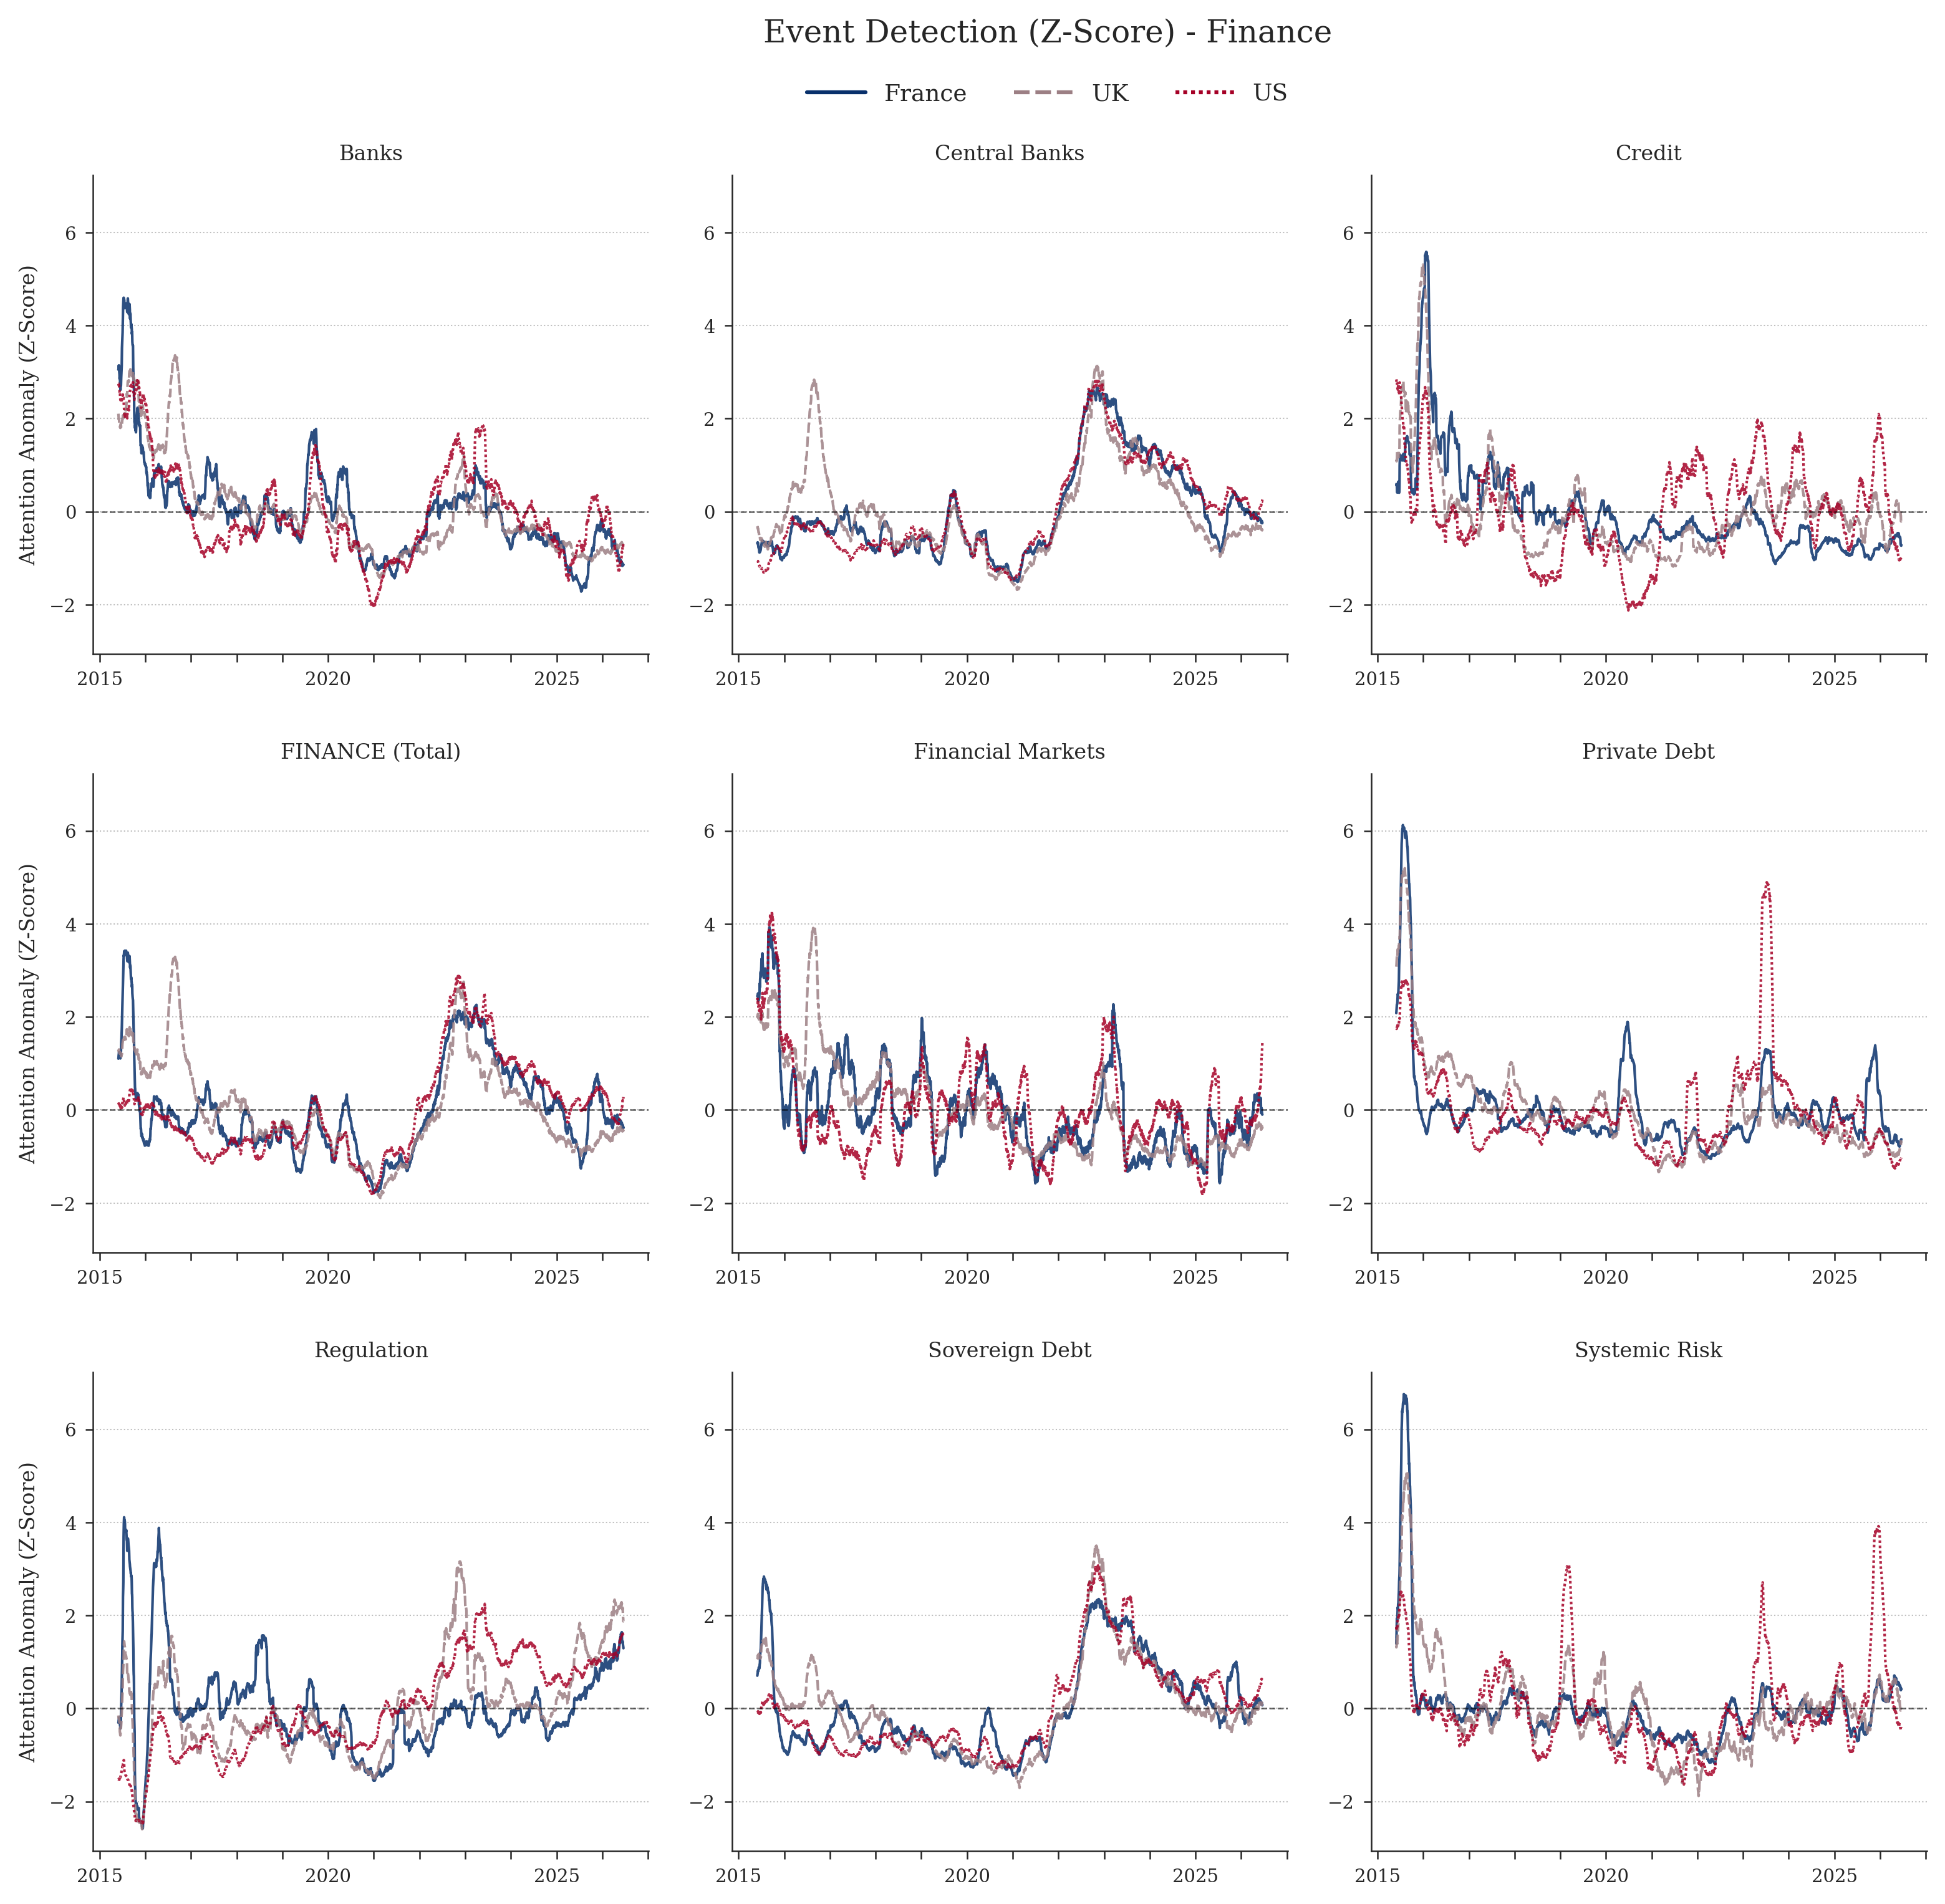

In [32]:
plot_academic_subsectors_zscore_grid(df_geo, sector_name="finance", regions=["US",  "UK", "France"], rolling_window=90, filename="./plots/attention_time_series/finance_subsectors_zscore.png")

✔ Planche Z-Score sauvegardée sous : ./plots/attention_time_series/finance_subsectors_zscore.png


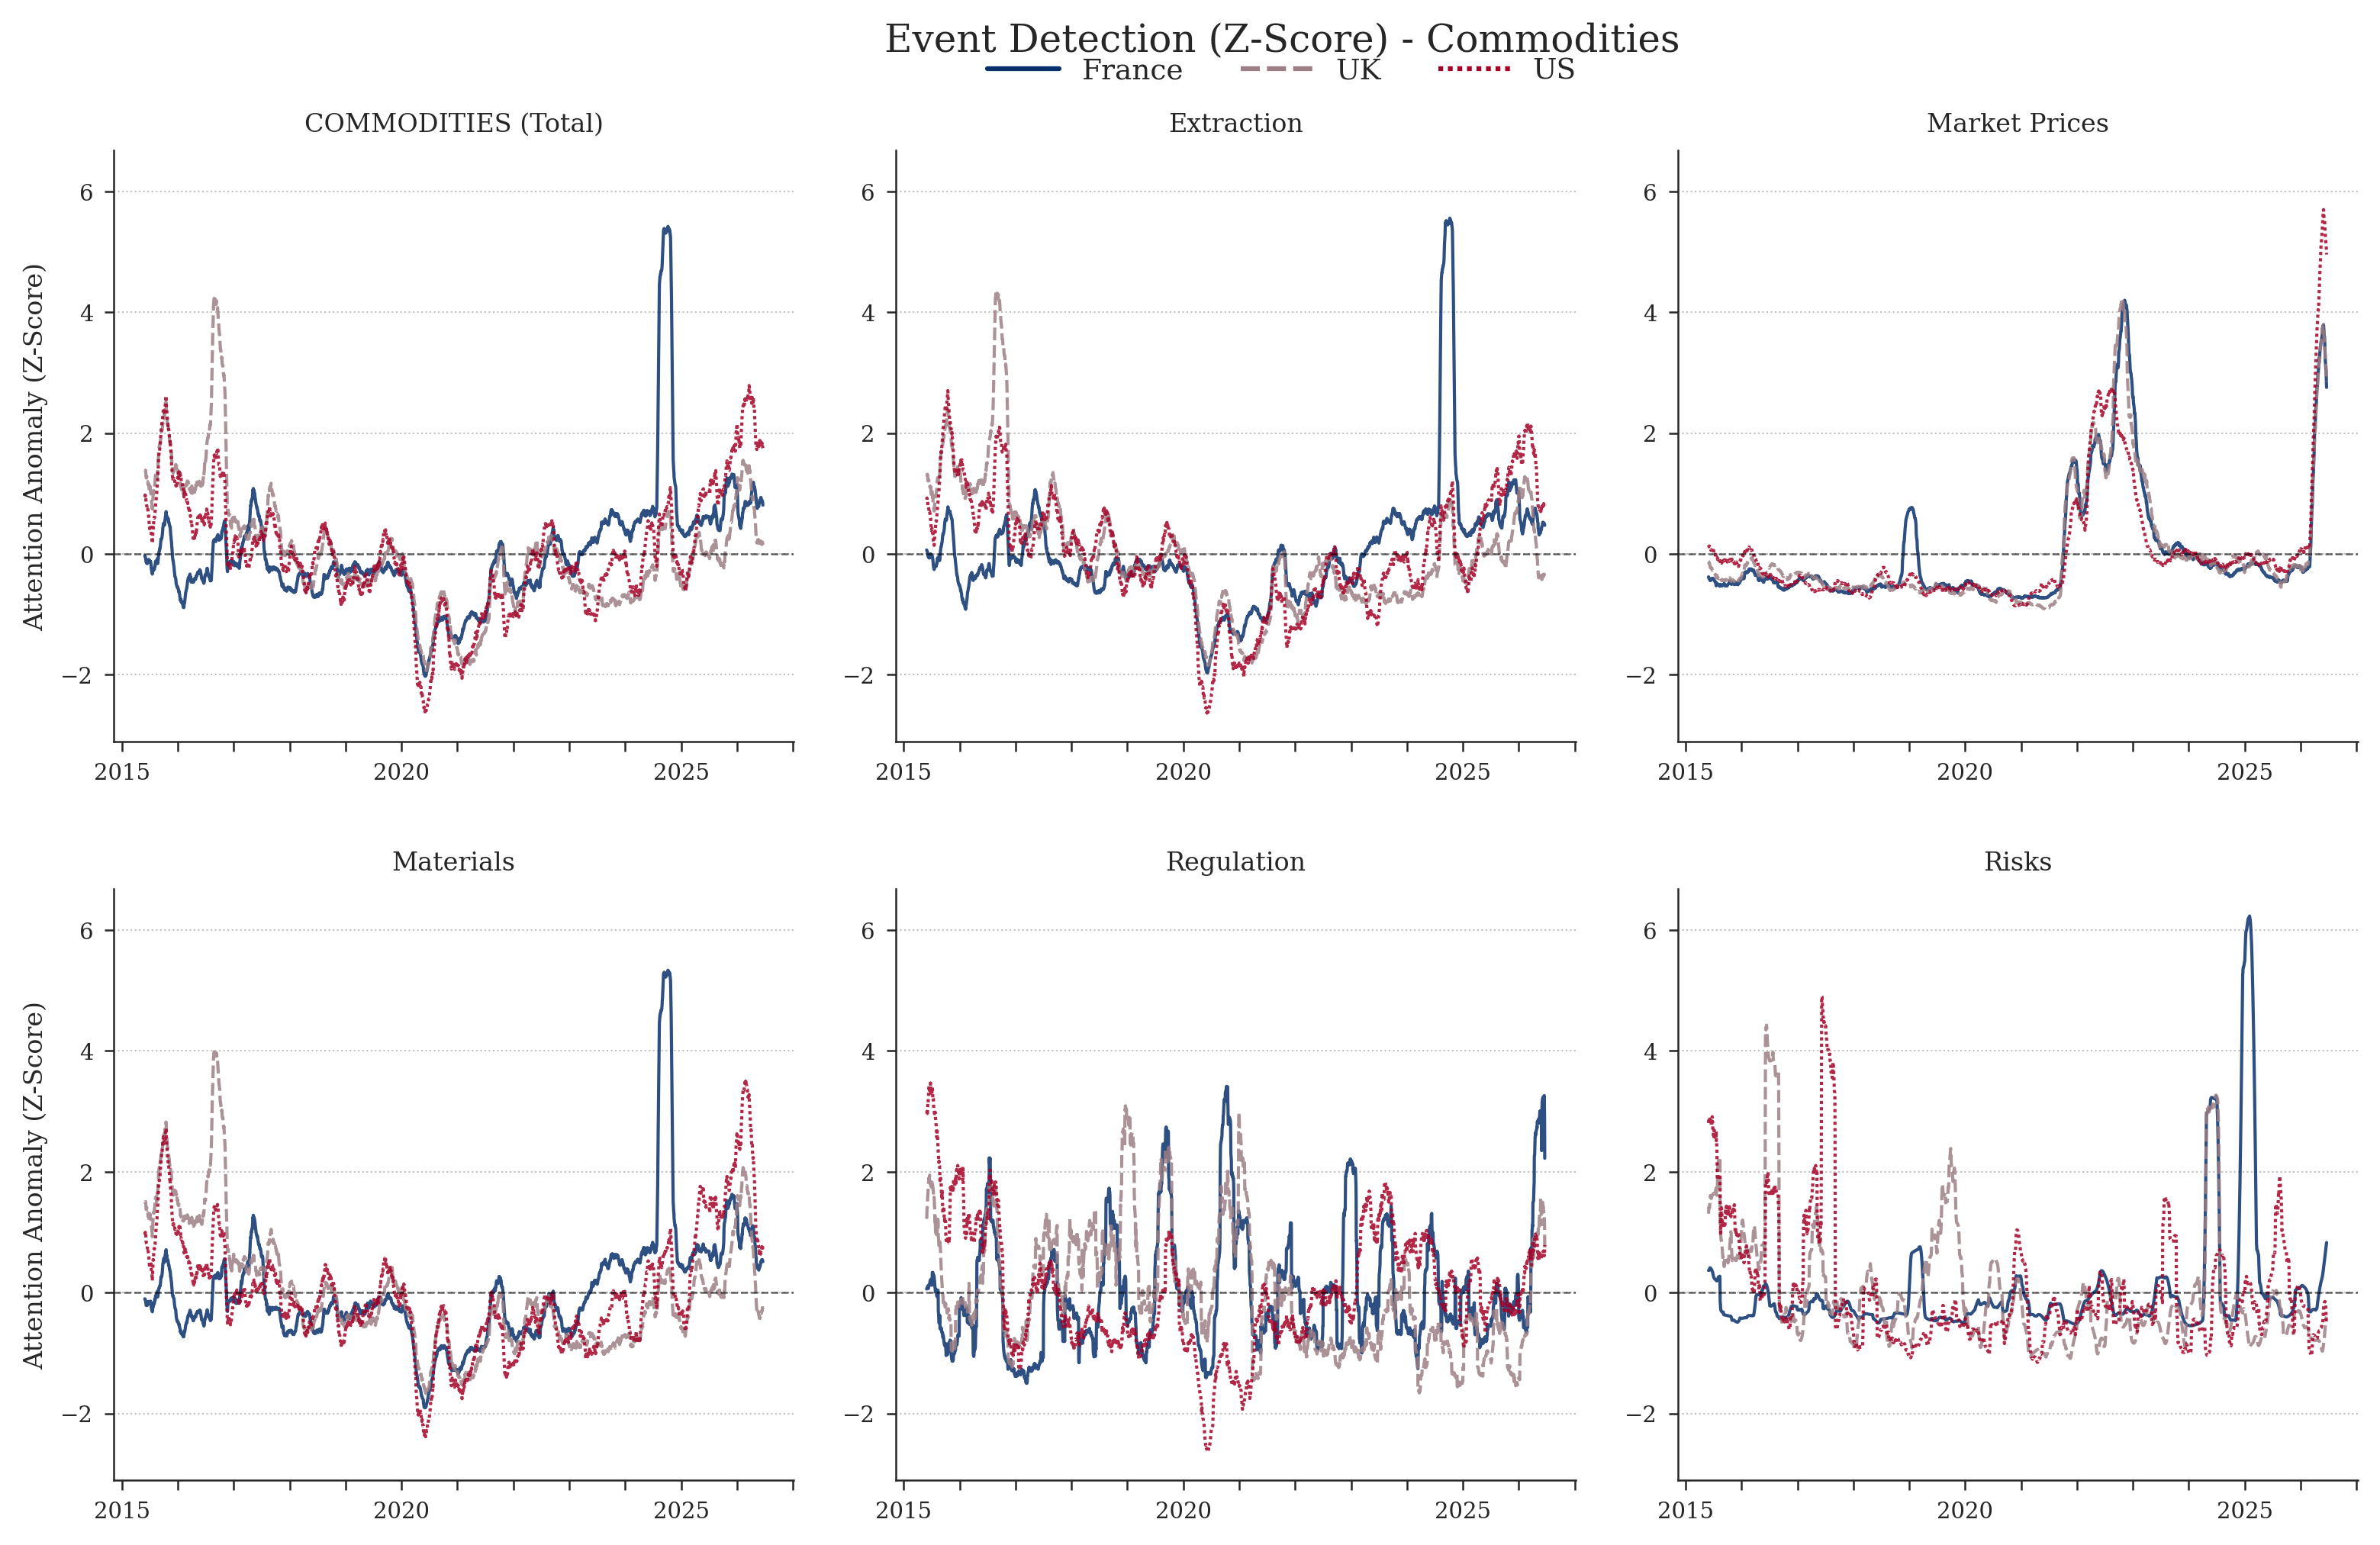

In [34]:
plot_academic_subsectors_zscore_grid(df_geo, sector_name="commodities", regions=["US",  "UK", "France"], rolling_window=90, filename="./plots/attention_time_series/finance_subsectors_zscore.png")

✔ Planche Z-Score sauvegardée sous : ./plots/attention_time_series/finance_subsectors_zscore.png


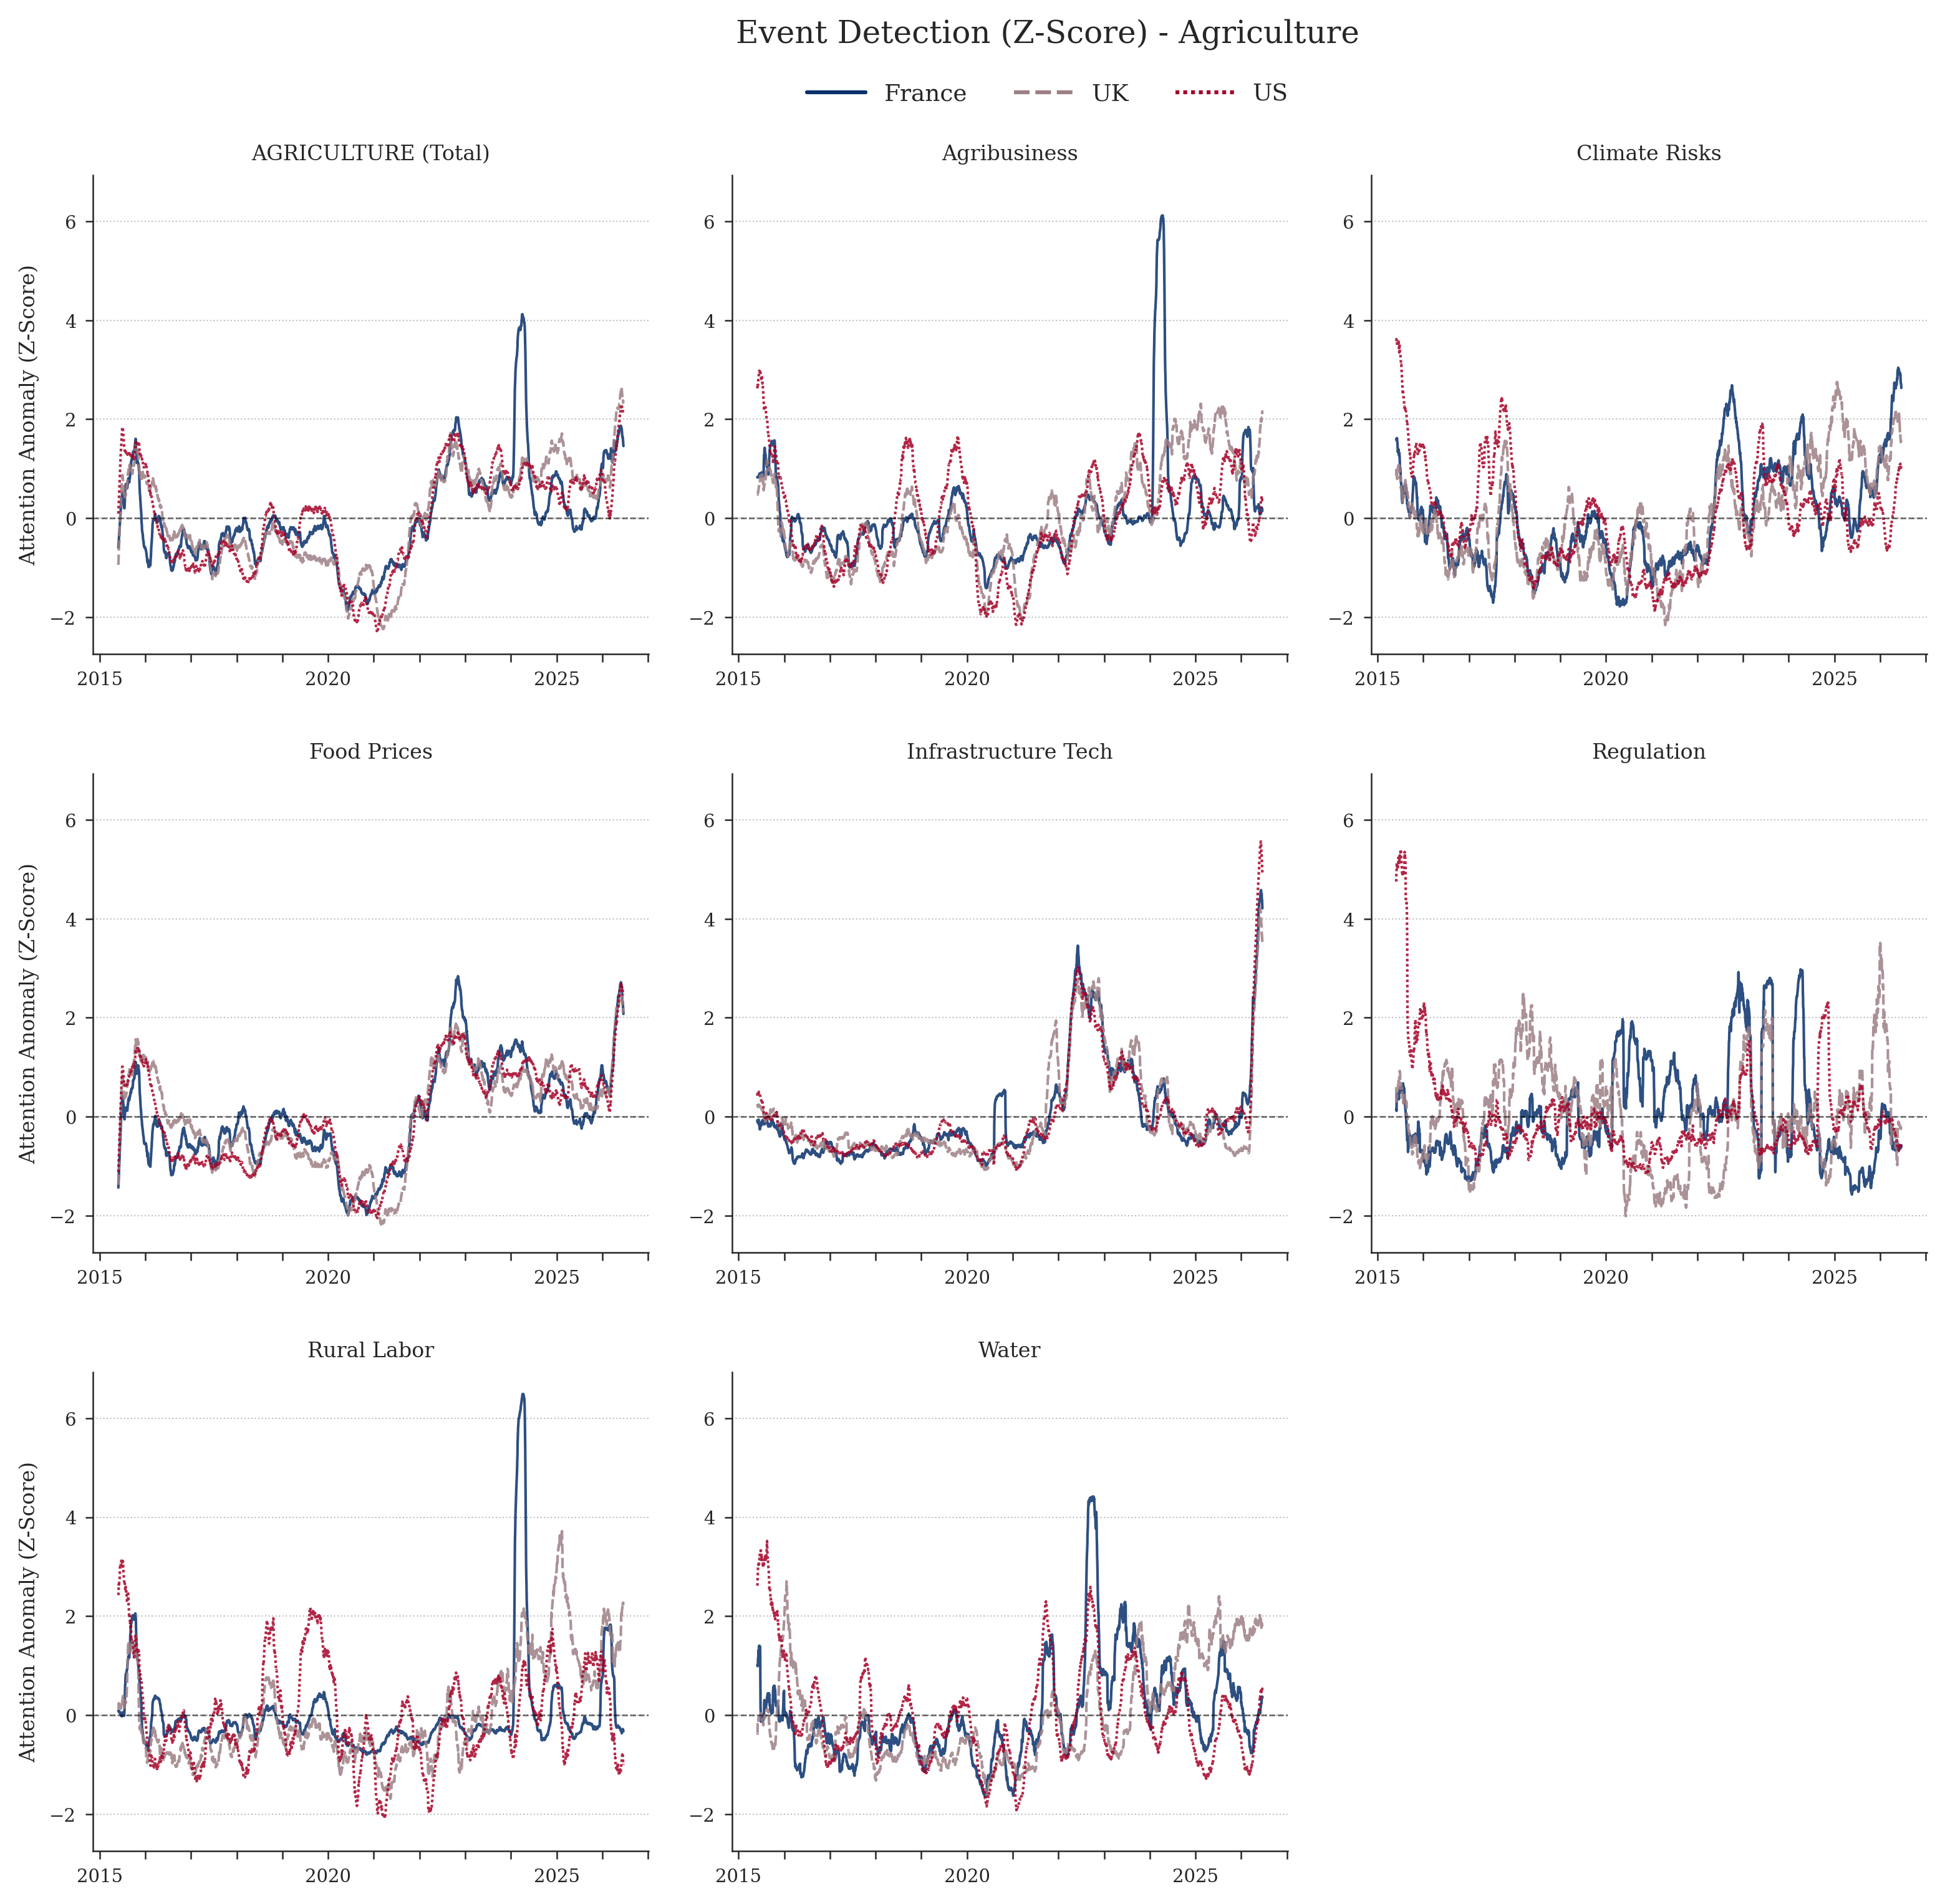

In [35]:
plot_academic_subsectors_zscore_grid(df_geo, sector_name="agriculture", regions=["US",  "UK", "France"], rolling_window=90, filename="./plots/attention_time_series/finance_subsectors_zscore.png")

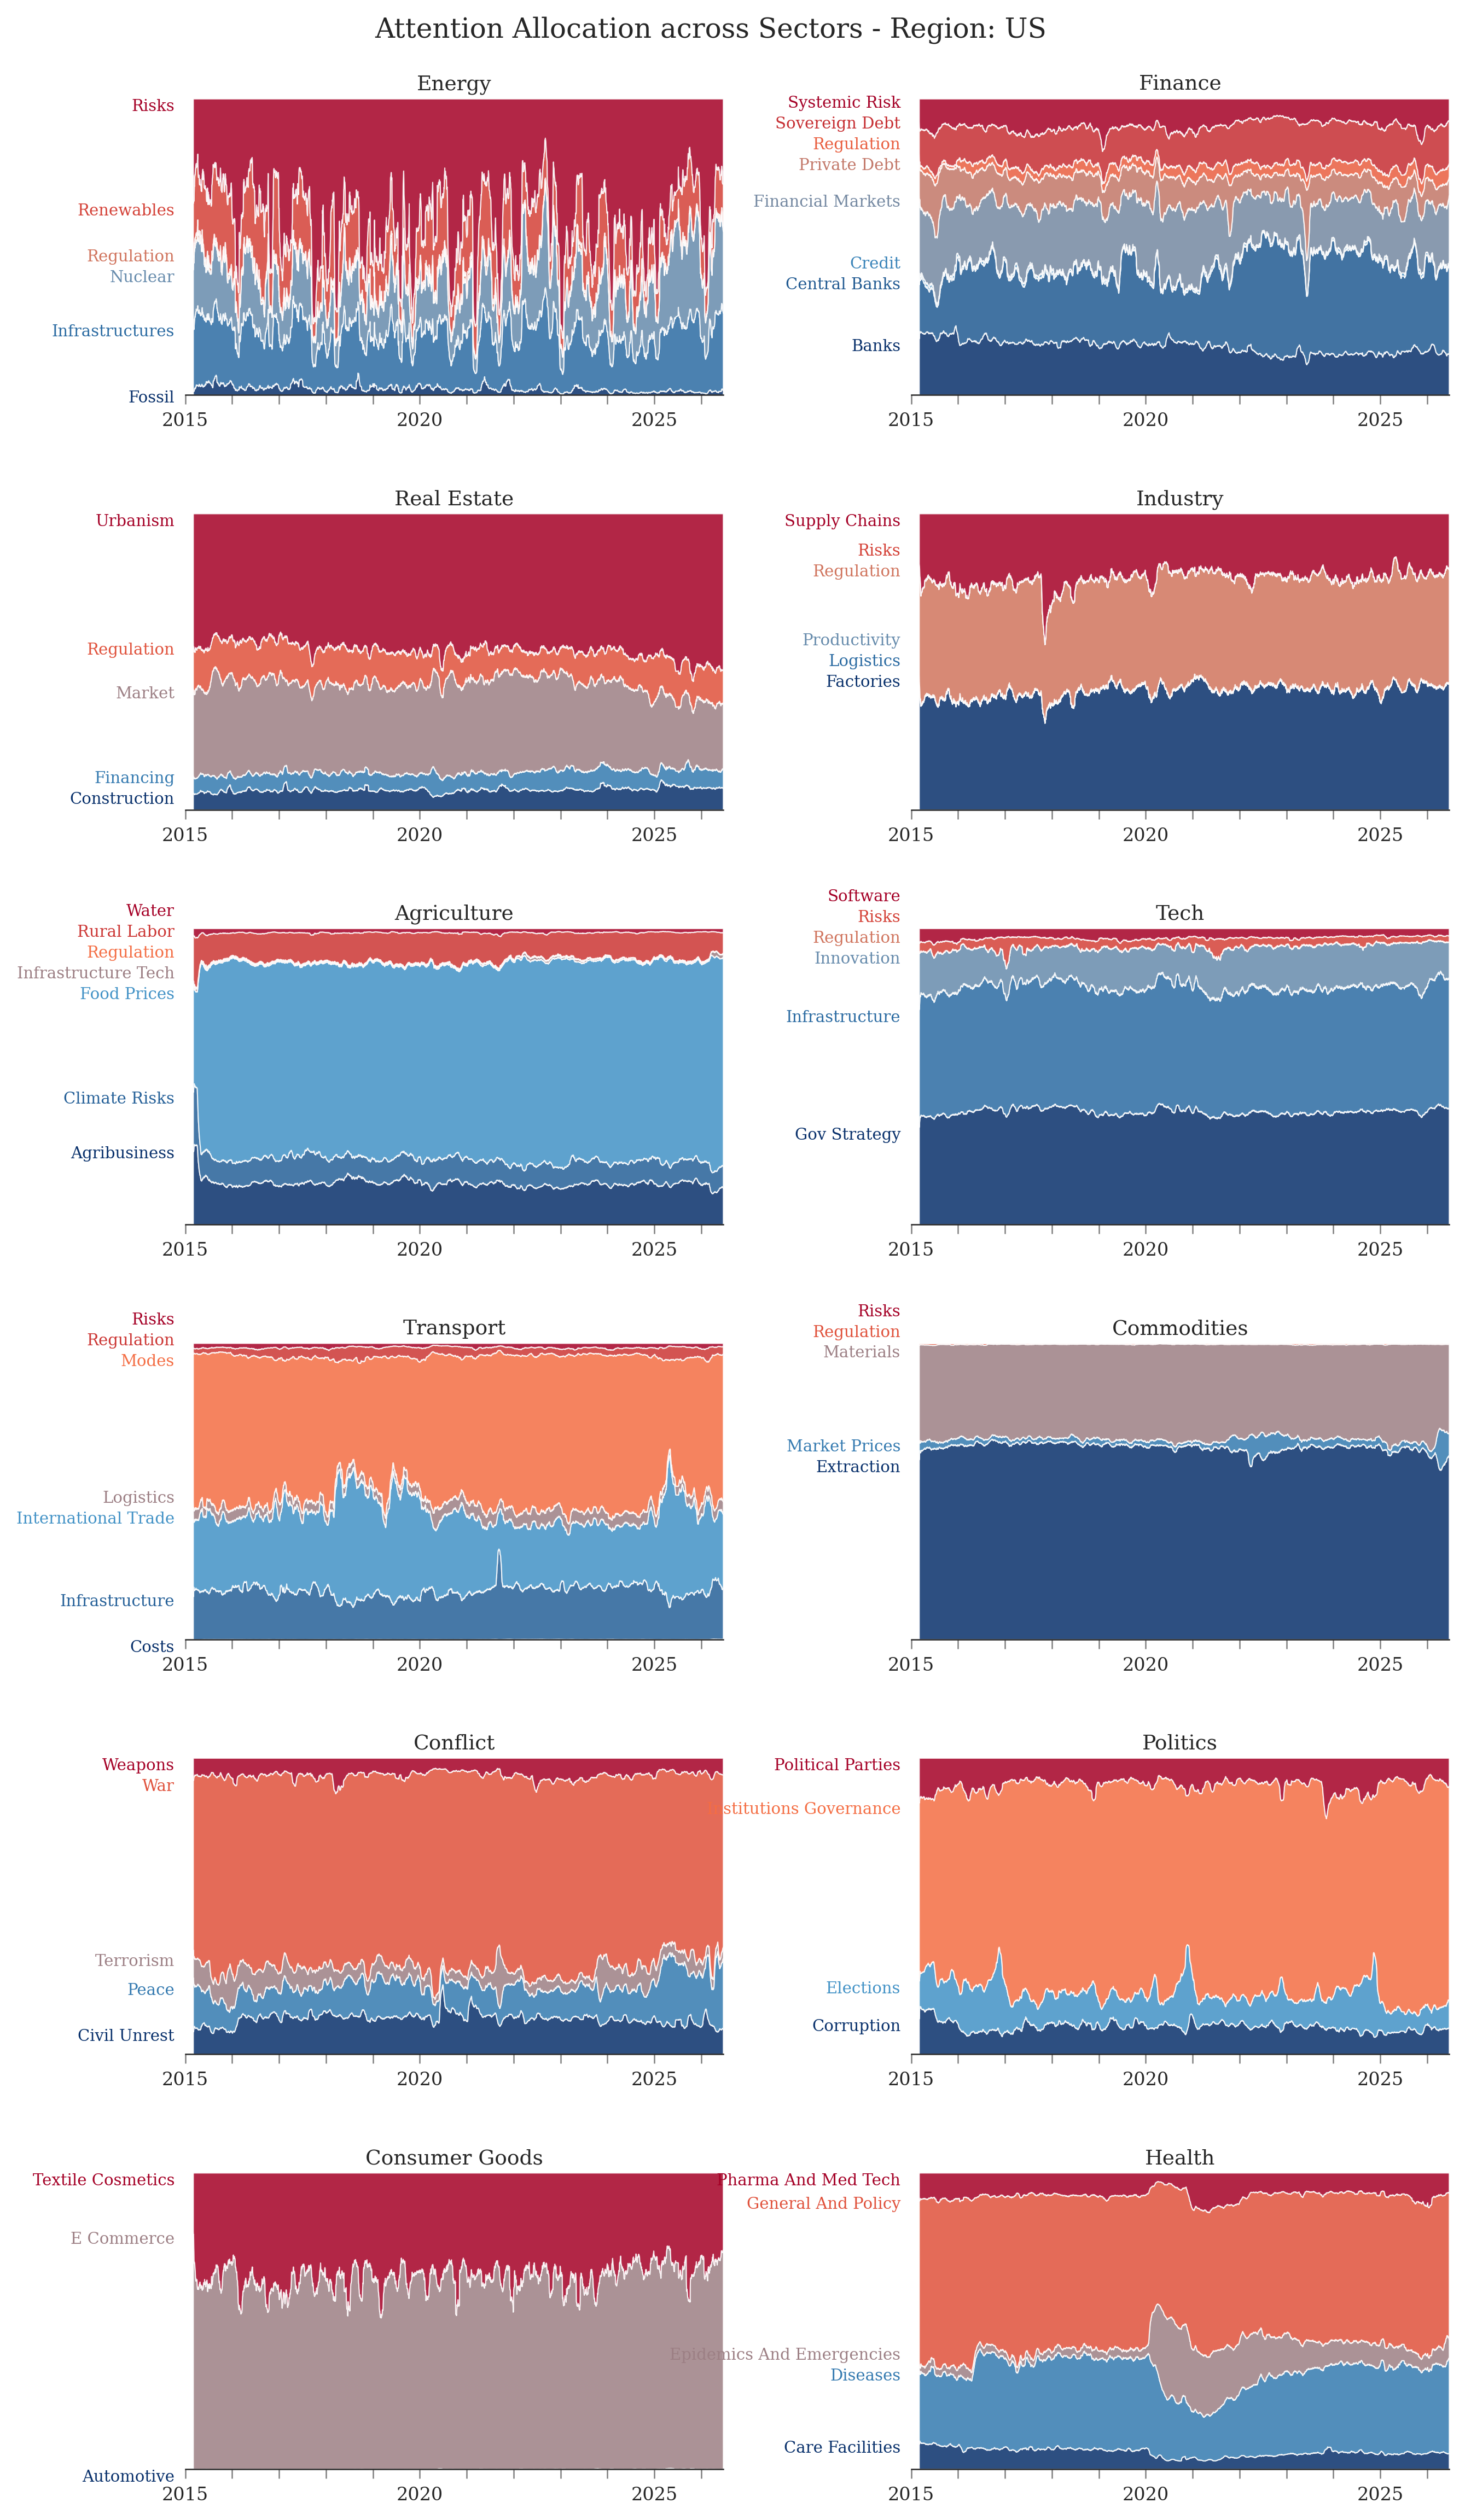

In [50]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import pandas as pd

# ==============================================================================
# GRILLE ACADÉMIQUE : ALLOCATION DE L'ATTENTION PAR SECTEUR (1 RÉGION)
# ==============================================================================

# 🎯 Paramètres
target_region = "US"  # À modifier selon la région souhaitée
lissage_jours = 30

# Configuration du style académique (minimaliste, serif)
plt.rcParams.update({
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.grid": False,
    "axes.facecolor": "white",
    "figure.facecolor": "white"
})

# 1. Identifier dynamiquement les secteurs (noms composés gérés)
all_att_cols = [c for c in df_geo.columns if c.startswith('att_weight_')]

sectors_dict = {}
for col in all_att_cols:
    if col != 'att_weight_growth':
        sector_candidate = col.replace('att_weight_', '')
        prefix = f"att_weight_{sector_candidate}_"
        subcats = [c for c in all_att_cols if c.startswith(prefix)]
        
        if len(subcats) > 0:
            sectors_dict[sector_candidate] = subcats

# 2. Préparation de la structure de la grille 
n_sectors = len(sectors_dict)
n_cols = 2
n_rows = int(np.ceil(n_sectors / n_cols))

# 🎯 MODIFICATION : Hauteur des lignes encore réduite (2.8 au lieu de 3.5)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 2.8 * n_rows), sharex=False)
axes = axes.flatten() if n_sectors > 1 else [axes]

# 3. Filtrage de la donnée pour la région cible
df_region = df_geo[df_geo['region_key'] == target_region].copy()
df_region = df_region.sort_values('period').set_index('period')

start_date = df_region.index.min()
end_date = df_region.index.max()

# Génération des tirets annuels et des labels sélectifs
annees_visibles = [2015, 2020, 2025]
toutes_les_annees = range(start_date.year, end_date.year + 1)

custom_ticks = [pd.to_datetime(f"{y}-01-01") for y in toutes_les_annees]
custom_labels = [str(y) if y in annees_visibles else "" for y in toutes_les_annees]

# 4. Génération des graphiques secteur par secteur
for idx, (sector, cols) in enumerate(sectors_dict.items()):
    ax = axes[idx]
    cols = sorted(cols)
    
    prefix_to_remove = f"att_weight_{sector}_"
    labels = [c.replace(prefix_to_remove, '').replace('_', ' ').title() for c in cols]
    
    df_smooth = df_region[cols].fillna(0).rolling(window=lissage_jours, min_periods=1).mean().fillna(0)
    
    total = df_smooth.sum(axis=1).replace(0, np.nan)
    df_norm = df_smooth.div(total, axis=0).fillna(0)
    
    colors = sns.blend_palette(["#08306b", "#4292c6", "#f46d43", "#a50026"], len(cols))
    
    ax.stackplot(
        df_norm.index, 
        df_norm.T, 
        colors=colors,
        alpha=0.85,
        linewidth=0.5,
        edgecolor='white'
    )
    
    # 🎯 MODIFICATION : Plus de gras, titre légèrement plus petit, espacement réduit (pad=4)
    ax.set_title(sector.replace('_', ' ').title(), fontweight='normal', fontsize=9, pad=4)
    ax.set_ylim(0, 1)
    ax.set_xlim(start_date, end_date)
    ax.margins(x=0)
    ax.set_yticks([]) 
    
    if len(df_norm) > 0:
        first_day_values = df_norm.iloc[0].values
        cumulative_heights = np.cumsum(first_day_values)
        
        y_positions = list(cumulative_heights)
        # Gap réduit pour s'adapter à la plus petite police
        min_gap = 0.07 
        for i in range(1, len(y_positions)):
            if y_positions[i] - y_positions[i-1] < min_gap:
                y_positions[i] = y_positions[i-1] + min_gap
        
        for i, label in enumerate(labels):
            ax.text(
                -0.02, y_positions[i], 
                label, 
                color=colors[i], 
                fontsize=7, # 🎯 Légendes plus discrètes
                fontweight='normal', # 🎯 Suppression du gras
                ha='right', 
                va='top',
                transform=ax.transAxes 
            )
        
    # APPLICATION DES DATES SUR L'AXE X (Sans gras, discrets)
    ax.set_xticks(custom_ticks)
    ax.set_xticklabels(custom_labels)
    ax.tick_params(axis='x', direction='out', length=4, labelsize=8, color='gray', labelbottom=True)

# 5. Nettoyage des cases vides
for idx in range(n_sectors, len(axes)):
    fig.delaxes(axes[idx])

# 🎯 On descend légèrement le titre (y=0.95)
fig.suptitle(f"Attention Allocation across Sectors - Region: {target_region}", 
             fontsize=12, fontweight='normal', y=0.95)

# 🎯 On remonte le haut des graphiques (top=0.92 au lieu de 0.88)
plt.subplots_adjust(left=0.18, right=0.95, top=0.92, bottom=0.06, hspace=0.40, wspace=0.35)
plt.show()

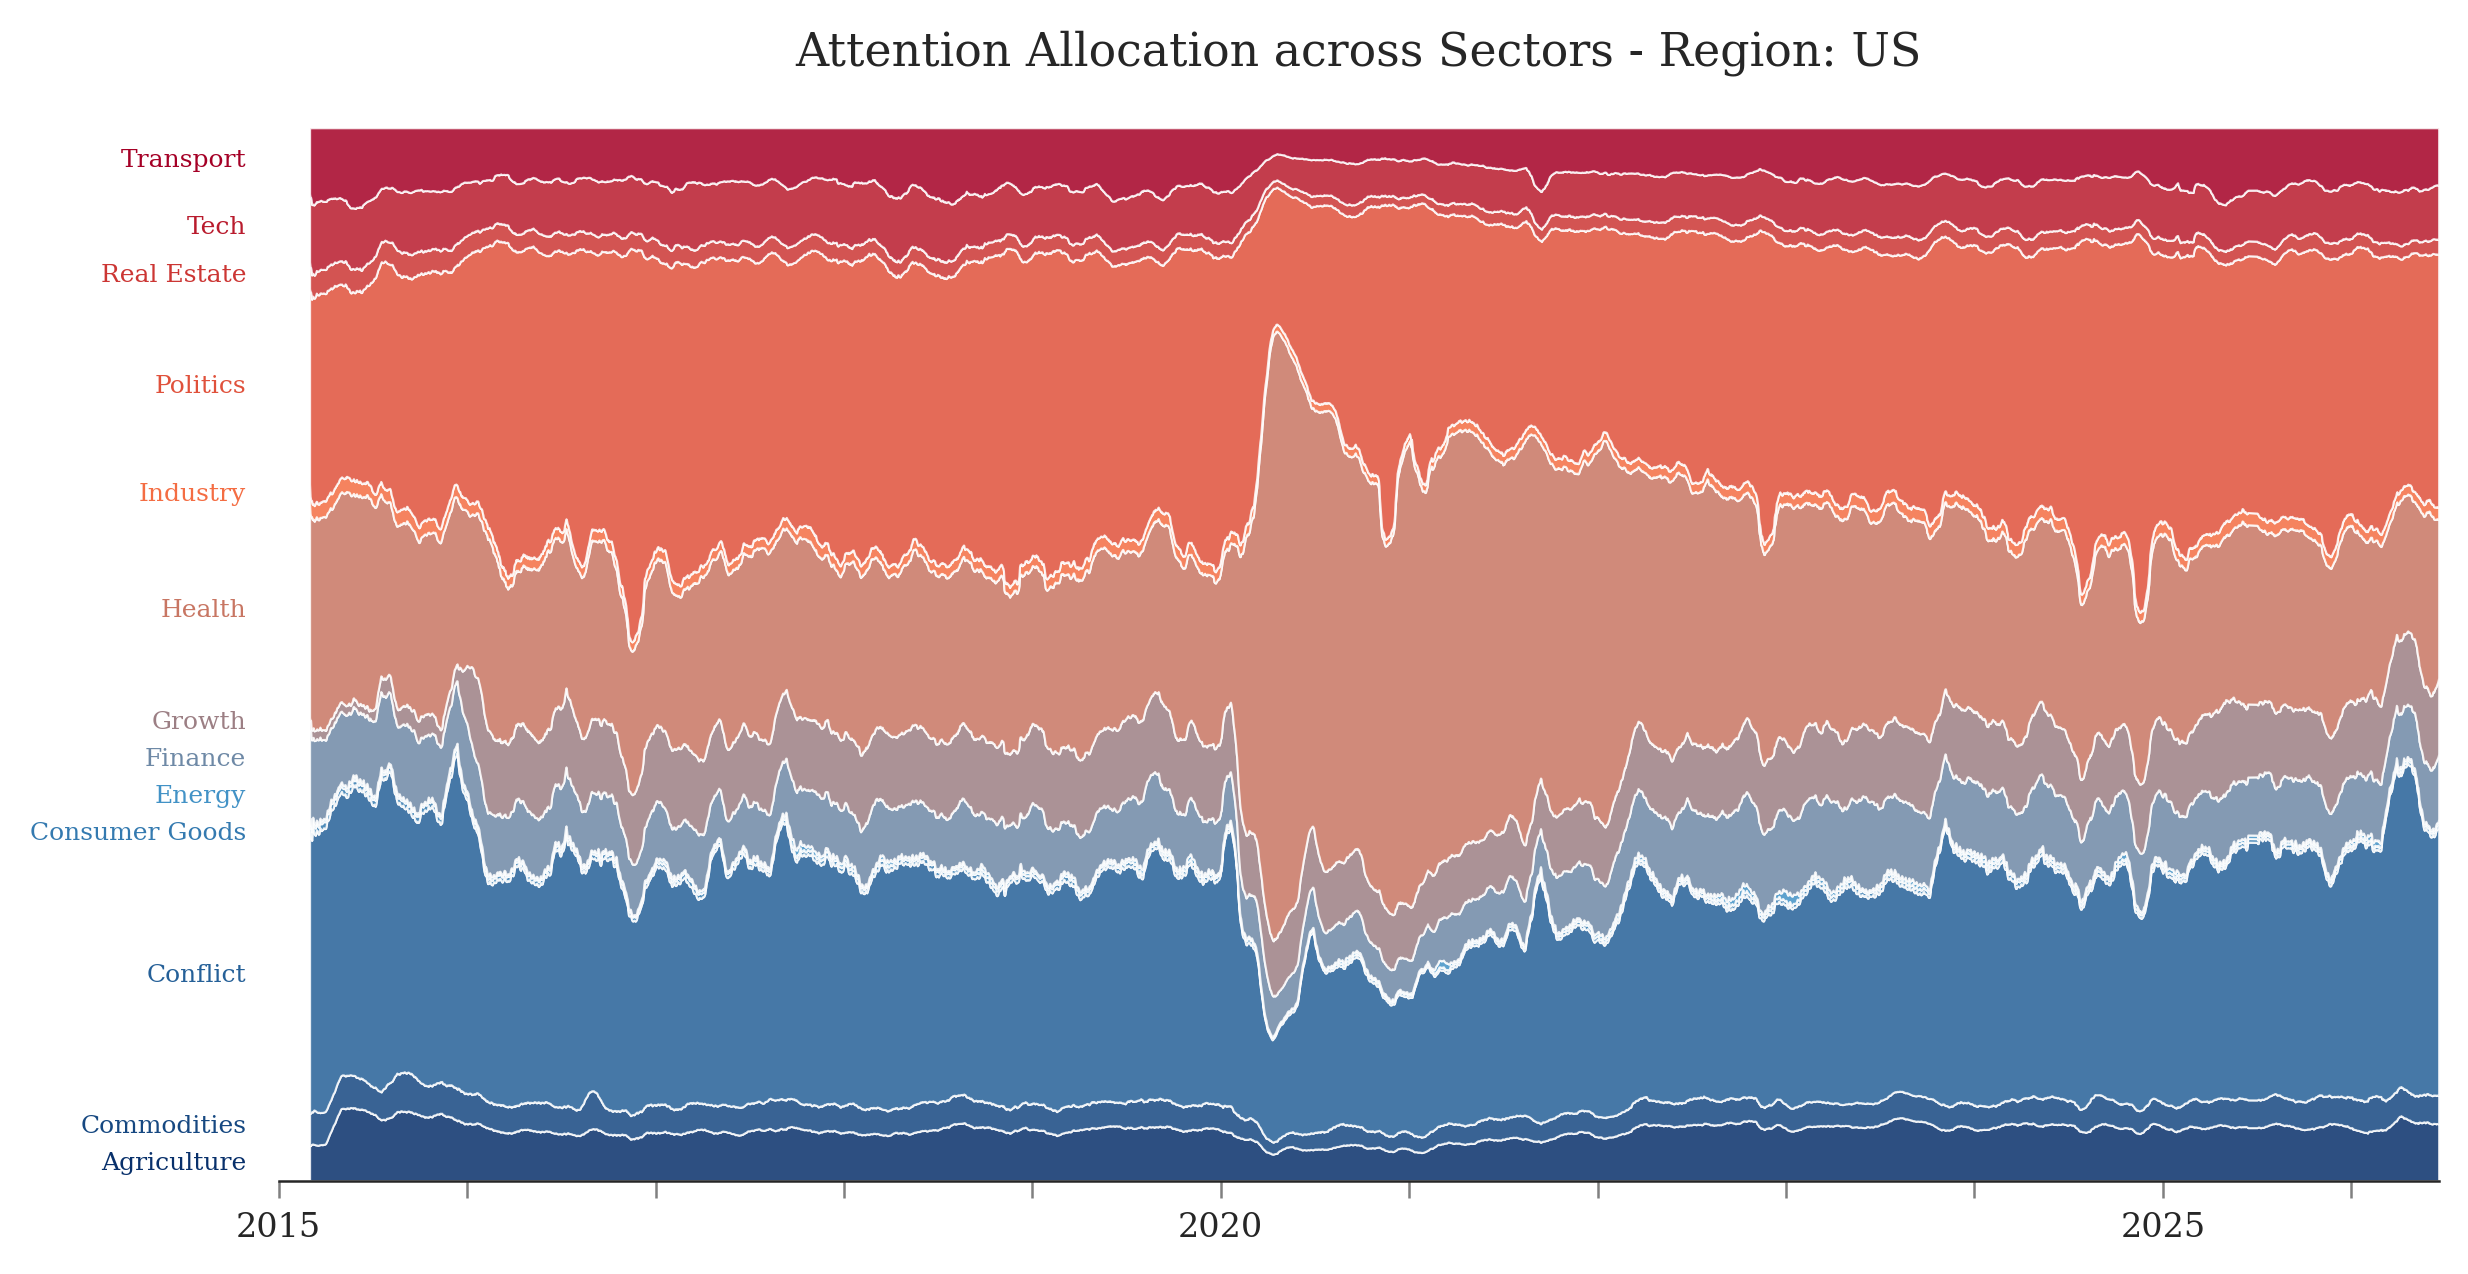

In [46]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import pandas as pd

# ==============================================================================
# GRAPHIQUE UNIQUE : ALLOCATION DE L'ATTENTION MACRO (LES 8 SECTEURS)
# ==============================================================================

# 🎯 Paramètres
target_region = "US"  
lissage_jours = 30

# Configuration du style académique (minimaliste, serif)
plt.rcParams.update({
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.grid": False,
    "axes.facecolor": "white",
    "figure.facecolor": "white"
})

# 1. Identifier dynamiquement les 8 grands secteurs
all_att_cols = [c for c in df_geo.columns if c.startswith('att_weight_')]
macro_sectors = []

# On déduit les secteurs globaux : ce sont ceux qui possèdent des sous-catégories
for col in all_att_cols:
    sector_candidate = col.replace('att_weight_', '')
    prefix = f"att_weight_{sector_candidate}_"
    subcats = [c for c in all_att_cols if c.startswith(prefix)]
    
    if len(subcats) > 0:
        macro_sectors.append(sector_candidate)

# Tri alphabétique pour une cohérence des couleurs et préparation des colonnes exactes
macro_sectors = sorted(macro_sectors)
macro_cols = [f"att_weight_{s}" for s in macro_sectors]
labels = [s.replace('_', ' ').title() for s in macro_sectors]

# 2. Préparation du graphique unique (Compact et allongé)
fig, ax = plt.subplots(figsize=(9, 4.5))

# 3. Filtrage de la donnée
df_region = df_geo[df_geo['region_key'] == target_region].copy()
df_region = df_region.sort_values('period').set_index('period')

start_date = df_region.index.min()
end_date = df_region.index.max()

# Génération des tirets annuels
annees_visibles = [2015, 2020, 2025]
toutes_les_annees = range(start_date.year, end_date.year + 1)
custom_ticks = [pd.to_datetime(f"{y}-01-01") for y in toutes_les_annees]
custom_labels = [str(y) if y in annees_visibles else "" for y in toutes_les_annees]

# 4. Traitement des données (Lissage et Normalisation)
df_smooth = df_region[macro_cols].fillna(0).rolling(window=lissage_jours, min_periods=1).mean().fillna(0)

# On recalcule le 100% basé uniquement sur la somme de ces 8 secteurs macroscopiques
total = df_smooth.sum(axis=1).replace(0, np.nan)
df_norm = df_smooth.div(total, axis=0).fillna(0)

# Camaïeu académique étiré sur les 8 secteurs
colors = sns.blend_palette(["#08306b", "#4292c6", "#f46d43", "#a50026"], len(macro_cols))

# 5. Tracé des aires empilées
ax.stackplot(
    df_norm.index, 
    df_norm.T, 
    colors=colors,
    alpha=0.85,
    linewidth=0.5,
    edgecolor='white'
)

# Esthétique du graphique (zéro gras)
ax.set_title(f"Attention Allocation across Sectors - Region: {target_region}", 
             fontweight='normal', fontsize=11, pad=15)
ax.set_ylim(0, 1)
ax.set_xlim(start_date, end_date)
ax.margins(x=0)
ax.set_yticks([]) 

# 6. Alignement physique des étiquettes à gauche (Centré sur les aires)
if len(df_norm) > 0:
    first_day_values = df_norm.iloc[0].values
    cumulative_heights = np.cumsum(first_day_values)
    
    # 1. Calculer le point central (milieu) de chaque bande de couleur
    bottoms = np.insert(cumulative_heights[:-1], 0, 0) # Départs (planchers) de chaque bande
    mid_positions = bottoms + (cumulative_heights - bottoms) / 2.0 # Milieux de chaque bande
    
    y_positions = list(mid_positions)
    min_gap = 0.035  # Espace minimum (légèrement réduit car on centre le texte)
    
    # 2. Logique anti-collision (on pousse vers le haut si ça se chevauche)
    for i in range(1, len(y_positions)):
        if y_positions[i] - y_positions[i-1] < min_gap:
            y_positions[i] = y_positions[i-1] + min_gap
            
    # On s'assure qu'aucun label ne dépasse tout en haut du graphique (y > 0.98)
    for i in range(len(y_positions)-2, -1, -1):
        if y_positions[i] > 0.98:
            y_positions[i] = 0.98
        if y_positions[i+1] - y_positions[i] < min_gap:
            y_positions[i] = y_positions[i+1] - min_gap
    
    # 3. Tracé des textes
    for i, label in enumerate(labels):
        ax.text(
            -0.015, y_positions[i], # Légèrement rapproché de l'axe (-0.015 au lieu de -0.02)
            label, 
            color=colors[i], 
            fontsize=6,           
            fontweight='normal',  
            ha='right', 
            va='center',          # 🎯 Changement crucial : on centre le mot sur le y_position
            transform=ax.transAxes 
        )
    
# 7. Axes temporels
ax.set_xticks(custom_ticks)
ax.set_xticklabels(custom_labels)
ax.tick_params(axis='x', direction='out', length=4, labelsize=8, color='gray')

# 8. Ajustement pour laisser de la place à la marge gauche (étiquettes)
plt.subplots_adjust(left=0.18, right=0.98, top=0.90, bottom=0.12)
plt.show()

### VIX 


[*********************100%***********************]  1 of 1 completed


✔ Graphique VIX vs GDELT généré avec succès.


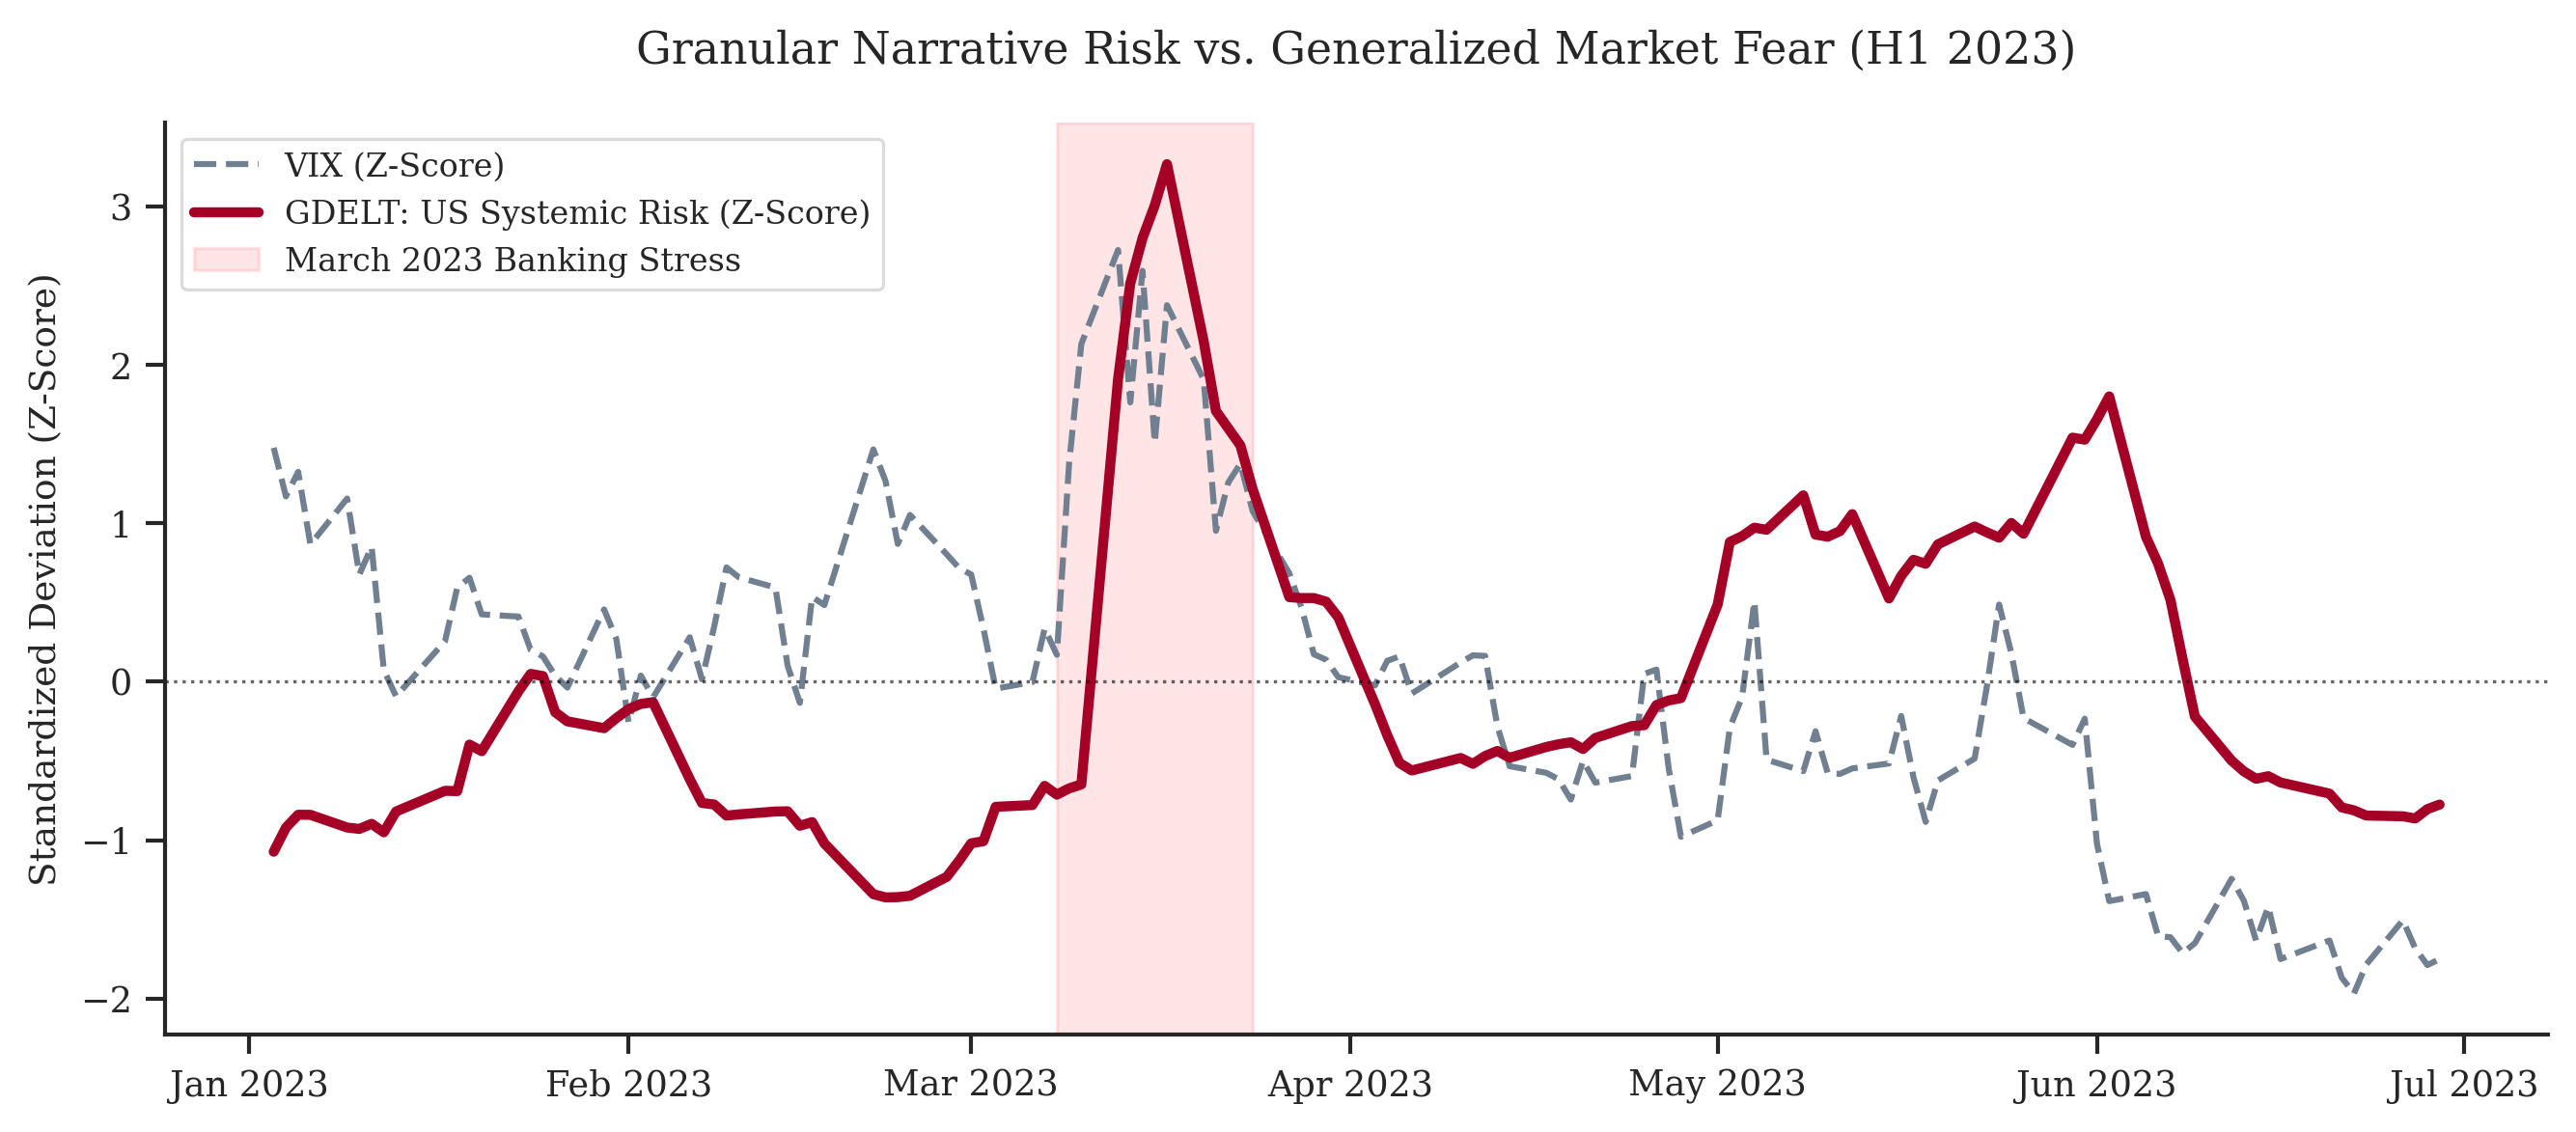

In [61]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ==========================================
# 1. PRÉPARATION DES DONNÉES GDELT
# ==========================================
# Isoler les données pour les Etats-Unis
df_us = df_geo[df_geo['region_key'] == 'US'].copy()
df_us['period'] = pd.to_datetime(df_us['period'])
df_us = df_us.set_index('period')

# On se concentre sur la période du 1er janvier 2023 au 30 juin 2023
df_us_2023 = df_us.loc['2023-01-01':'2023-06-30', ['att_weight_finance_systemic_risk']].copy()

# Lissage sur 7 jours pour réduire le bruit quotidien tout en gardant la réactivité
df_us_2023['GDELT_smoothed'] = df_us_2023['att_weight_finance_systemic_risk'].rolling(window=7, min_periods=1).mean()

# ==========================================
# 2. TÉLÉCHARGEMENT DES DONNÉES VIX
# ==========================================
vix_data = yf.download('^VIX', start='2023-01-01', end='2023-06-30')

# Extraire la colonne Close de yfinance
if isinstance(vix_data.columns, pd.MultiIndex):
    vix_close = vix_data['Close']['^VIX']
else:
    vix_close = vix_data['Close']
    
df_vix = pd.DataFrame({'VIX': vix_close})
df_vix.index = pd.to_datetime(df_vix.index).tz_localize(None)

# ==========================================
# 3. FUSION ET NORMALISATION (Z-SCORES)
# ==========================================
df_plot = df_vix.join(df_us_2023, how='inner').dropna()

# Calculer les Z-Scores : (Valeur - Moyenne) / Ecart-Type
df_plot['VIX_Z'] = (df_plot['VIX'] - df_plot['VIX'].mean()) / df_plot['VIX'].std()
df_plot['GDELT_Z'] = (df_plot['GDELT_smoothed'] - df_plot['GDELT_smoothed'].mean()) / df_plot['GDELT_smoothed'].std()

# ==========================================
# 4. VISUALISATION ACADÉMIQUE
# ==========================================
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update({
    "font.family": "serif",
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "figure.dpi": 300,
})

fig, ax = plt.subplots(figsize=(9, 4))

# Tracer les deux courbes
ax.plot(df_plot.index, df_plot['VIX_Z'], color='slategray', linewidth=1.5, linestyle='--', label='VIX (Z-Score)')
ax.plot(df_plot.index, df_plot['GDELT_Z'], color='#a50026', linewidth=2.5, label='GDELT: US Systemic Risk (Z-Score)')

# Ajouter l'ombre rouge pour la crise SVB / Credit Suisse (Mars 2023)
ax.axvspan(pd.to_datetime('2023-03-08'), pd.to_datetime('2023-03-24'), 
           color='red', alpha=0.1, label='March 2023 Banking Stress')

# Ligne de base
ax.axhline(0, color='black', linewidth=0.8, linestyle=':', alpha=0.6)

# Finitions
ax.set_title('Granular Narrative Risk vs. Generalized Market Fear (H1 2023)', pad=15)
ax.set_ylabel('Standardized Deviation (Z-Score)')
ax.set_xlabel('')

# Formatage de l'axe des dates
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
sns.despine()

# Légende
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='lightgray', fontsize=8)

plt.tight_layout()

# Sauvegarde pour la thèse
filename = './plots/attention_time_series/Fig_VIX_vs_SystemicRisk.pdf'
# Décommentez la ligne ci-dessous si le dossier "plots/attention_time_series" est bien créé
# plt.savefig(filename, bbox_inches='tight')

print("✔ Graphique VIX vs GDELT généré avec succès.")
plt.show()

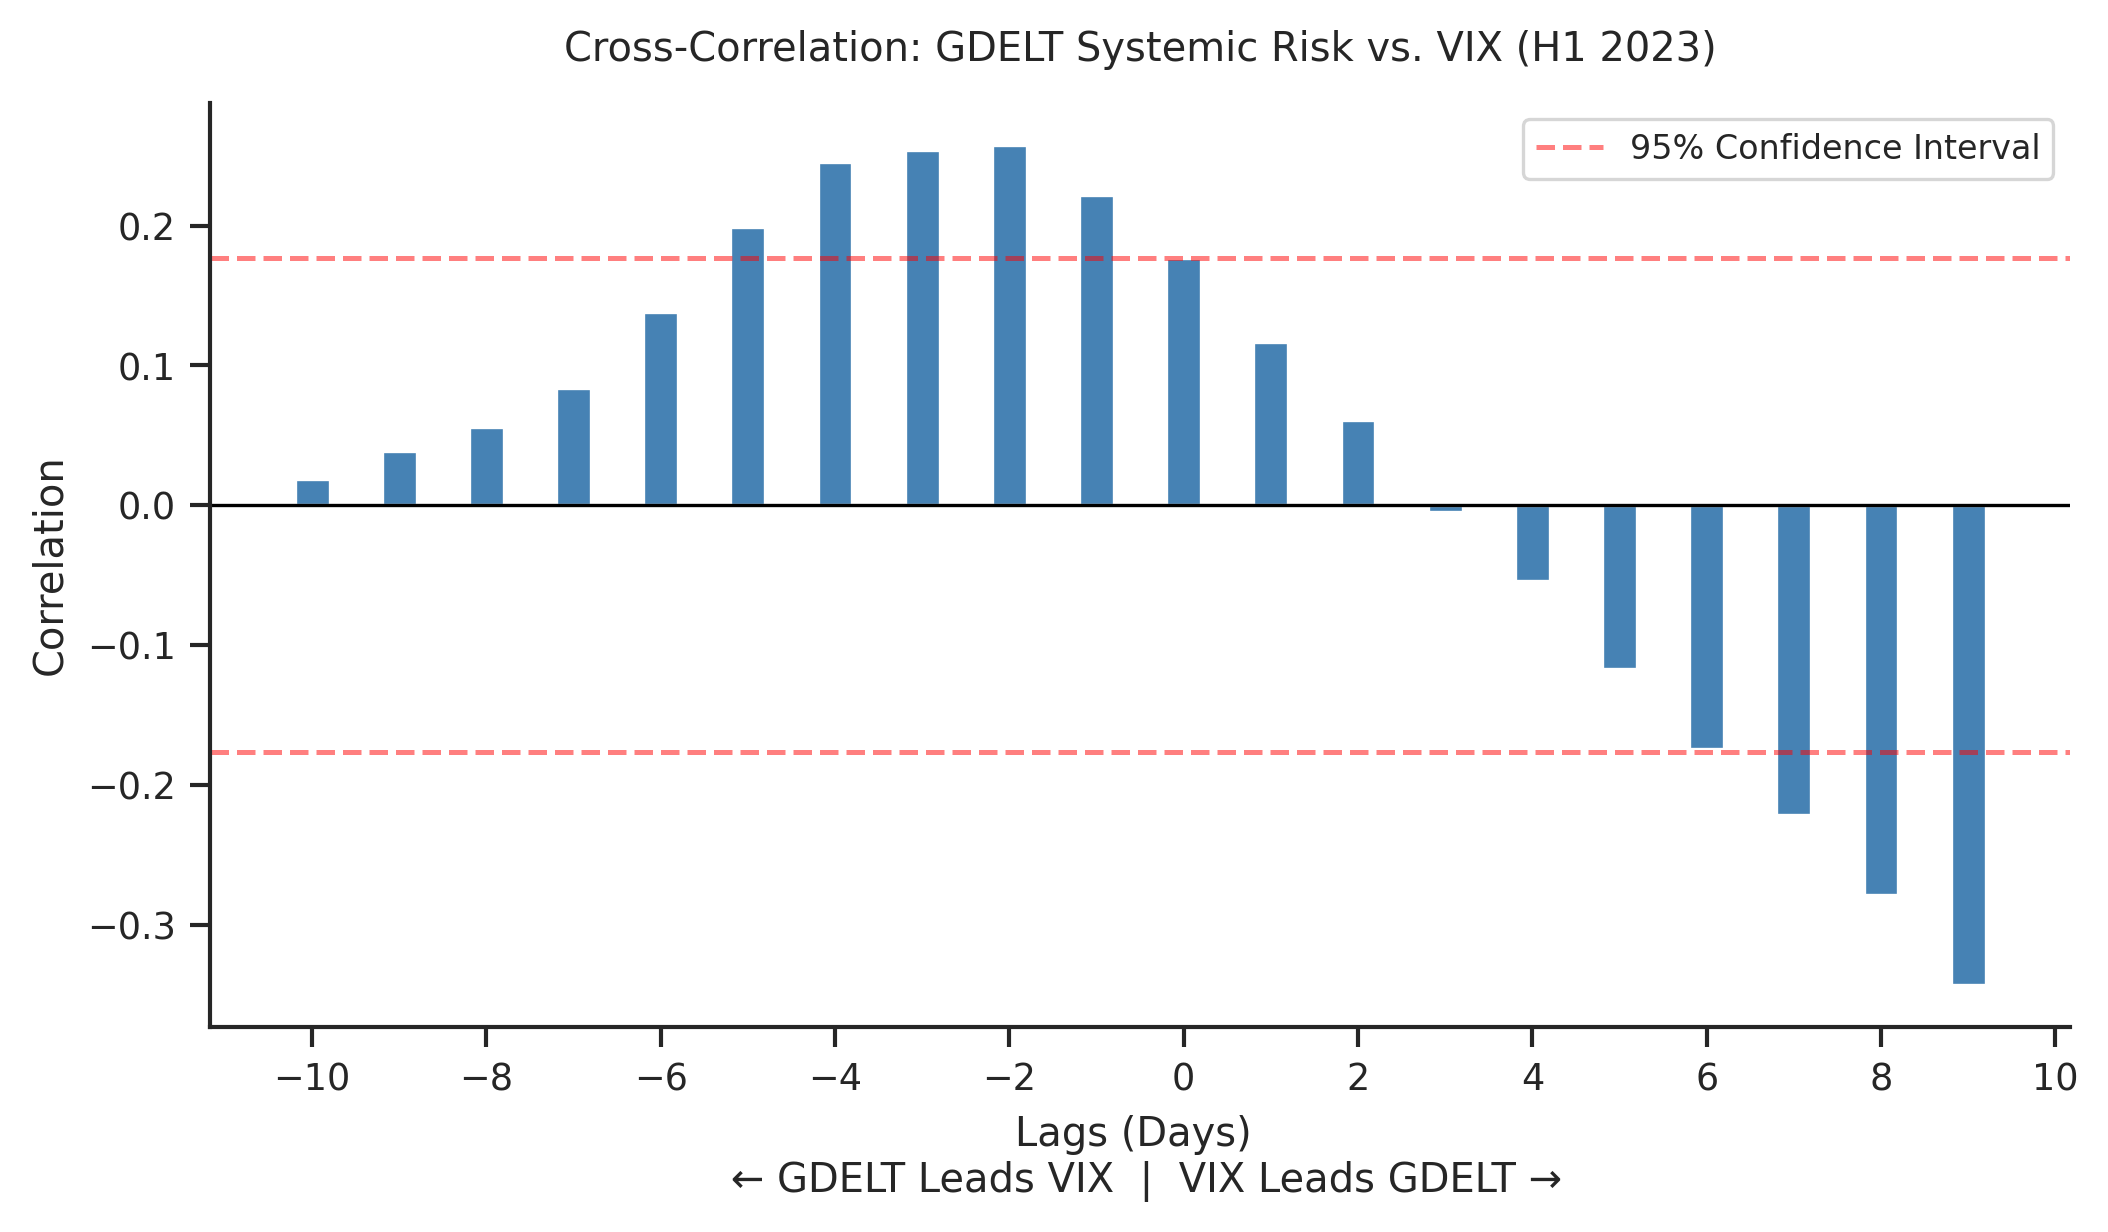


--- Granger Causality Test Results ---

1. Does GDELT Systemic Risk Granger-cause VIX?
Lag 1: p-value = 0.3016 
Lag 2: p-value = 0.4401 
Lag 3: p-value = 0.3123 

2. Does VIX Granger-cause GDELT Systemic Risk?
Lag 1: p-value = 0.0206 *** Significant
Lag 2: p-value = 0.2099 
Lag 3: p-value = 0.0105 *** Significant


/home/clucas/venvs/gdelt/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/clucas/venvs/gdelt/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [62]:
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import ccf, grangercausalitytests
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure no NaNs in the data
df_stat = df_plot[['VIX_Z', 'GDELT_Z']].dropna()

# ==========================================
# 1. CROSS-CORRELATION FUNCTION (LEAD-LAG)
# ==========================================
# Calculate CCF: VIX vs lagged/leaded GDELT
lags_forward = ccf(df_stat['VIX_Z'], df_stat['GDELT_Z'], adjusted=False)[:10]  # GDELT lags VIX
lags_backward = ccf(df_stat['GDELT_Z'], df_stat['VIX_Z'], adjusted=False)[1:11] # GDELT leads VIX

# Combine into a single array from -10 to +9
ccf_values = np.concatenate((lags_backward[::-1], lags_forward))
lags = np.arange(-10, 10)

# Plotting the CCF
sns.set_theme(style="ticks", context="paper")
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(lags, ccf_values, color='steelblue', width=0.4)
ax.axhline(0, color='black', linewidth=0.8)

# Significance bounds (approximate 95% confidence interval)
conf_level = 1.96 / np.sqrt(len(df_stat))
ax.axhline(conf_level, color='red', linestyle='--', alpha=0.5, label='95% Confidence Interval')
ax.axhline(-conf_level, color='red', linestyle='--', alpha=0.5)

ax.set_title('Cross-Correlation: GDELT Systemic Risk vs. VIX (H1 2023)', pad=10)
ax.set_xlabel('Lags (Days) \n ← GDELT Leads VIX  |  VIX Leads GDELT →')
ax.set_ylabel('Correlation')
ax.set_xticks(np.arange(-10, 11, 2))
ax.legend(loc='upper right', fontsize=8)
sns.despine()

# Save plot for thesis
# plt.savefig('./plots/attention_time_series/Fig_CCF_VIX_GDELT.pdf', bbox_inches='tight')
plt.show()

# ==========================================
# 2. GRANGER CAUSALITY TESTS
# ==========================================
print("\n--- Granger Causality Test Results ---")
max_lag = 3

print("\n1. Does GDELT Systemic Risk Granger-cause VIX?")
# The second column is the predictor. We test if GDELT_Z causes VIX_Z
gc_res_1 = grangercausalitytests(df_stat[['VIX_Z', 'GDELT_Z']], maxlag=max_lag, verbose=False)
for lag in range(1, max_lag + 1):
    p_val = gc_res_1[lag][0]['ssr_ftest'][1]
    print(f"Lag {lag}: p-value = {p_val:.4f} {'*** Significant' if p_val < 0.05 else ''}")

print("\n2. Does VIX Granger-cause GDELT Systemic Risk?")
# We test if VIX_Z causes GDELT_Z
gc_res_2 = grangercausalitytests(df_stat[['GDELT_Z', 'VIX_Z']], maxlag=max_lag, verbose=False)
for lag in range(1, max_lag + 1):
    p_val = gc_res_2[lag][0]['ssr_ftest'][1]
    print(f"Lag {lag}: p-value = {p_val:.4f} {'*** Significant' if p_val < 0.05 else ''}")

[*********************100%***********************]  1 of 1 completed

Fetching VIX data from 2015-03-02 to 2026-06-19...


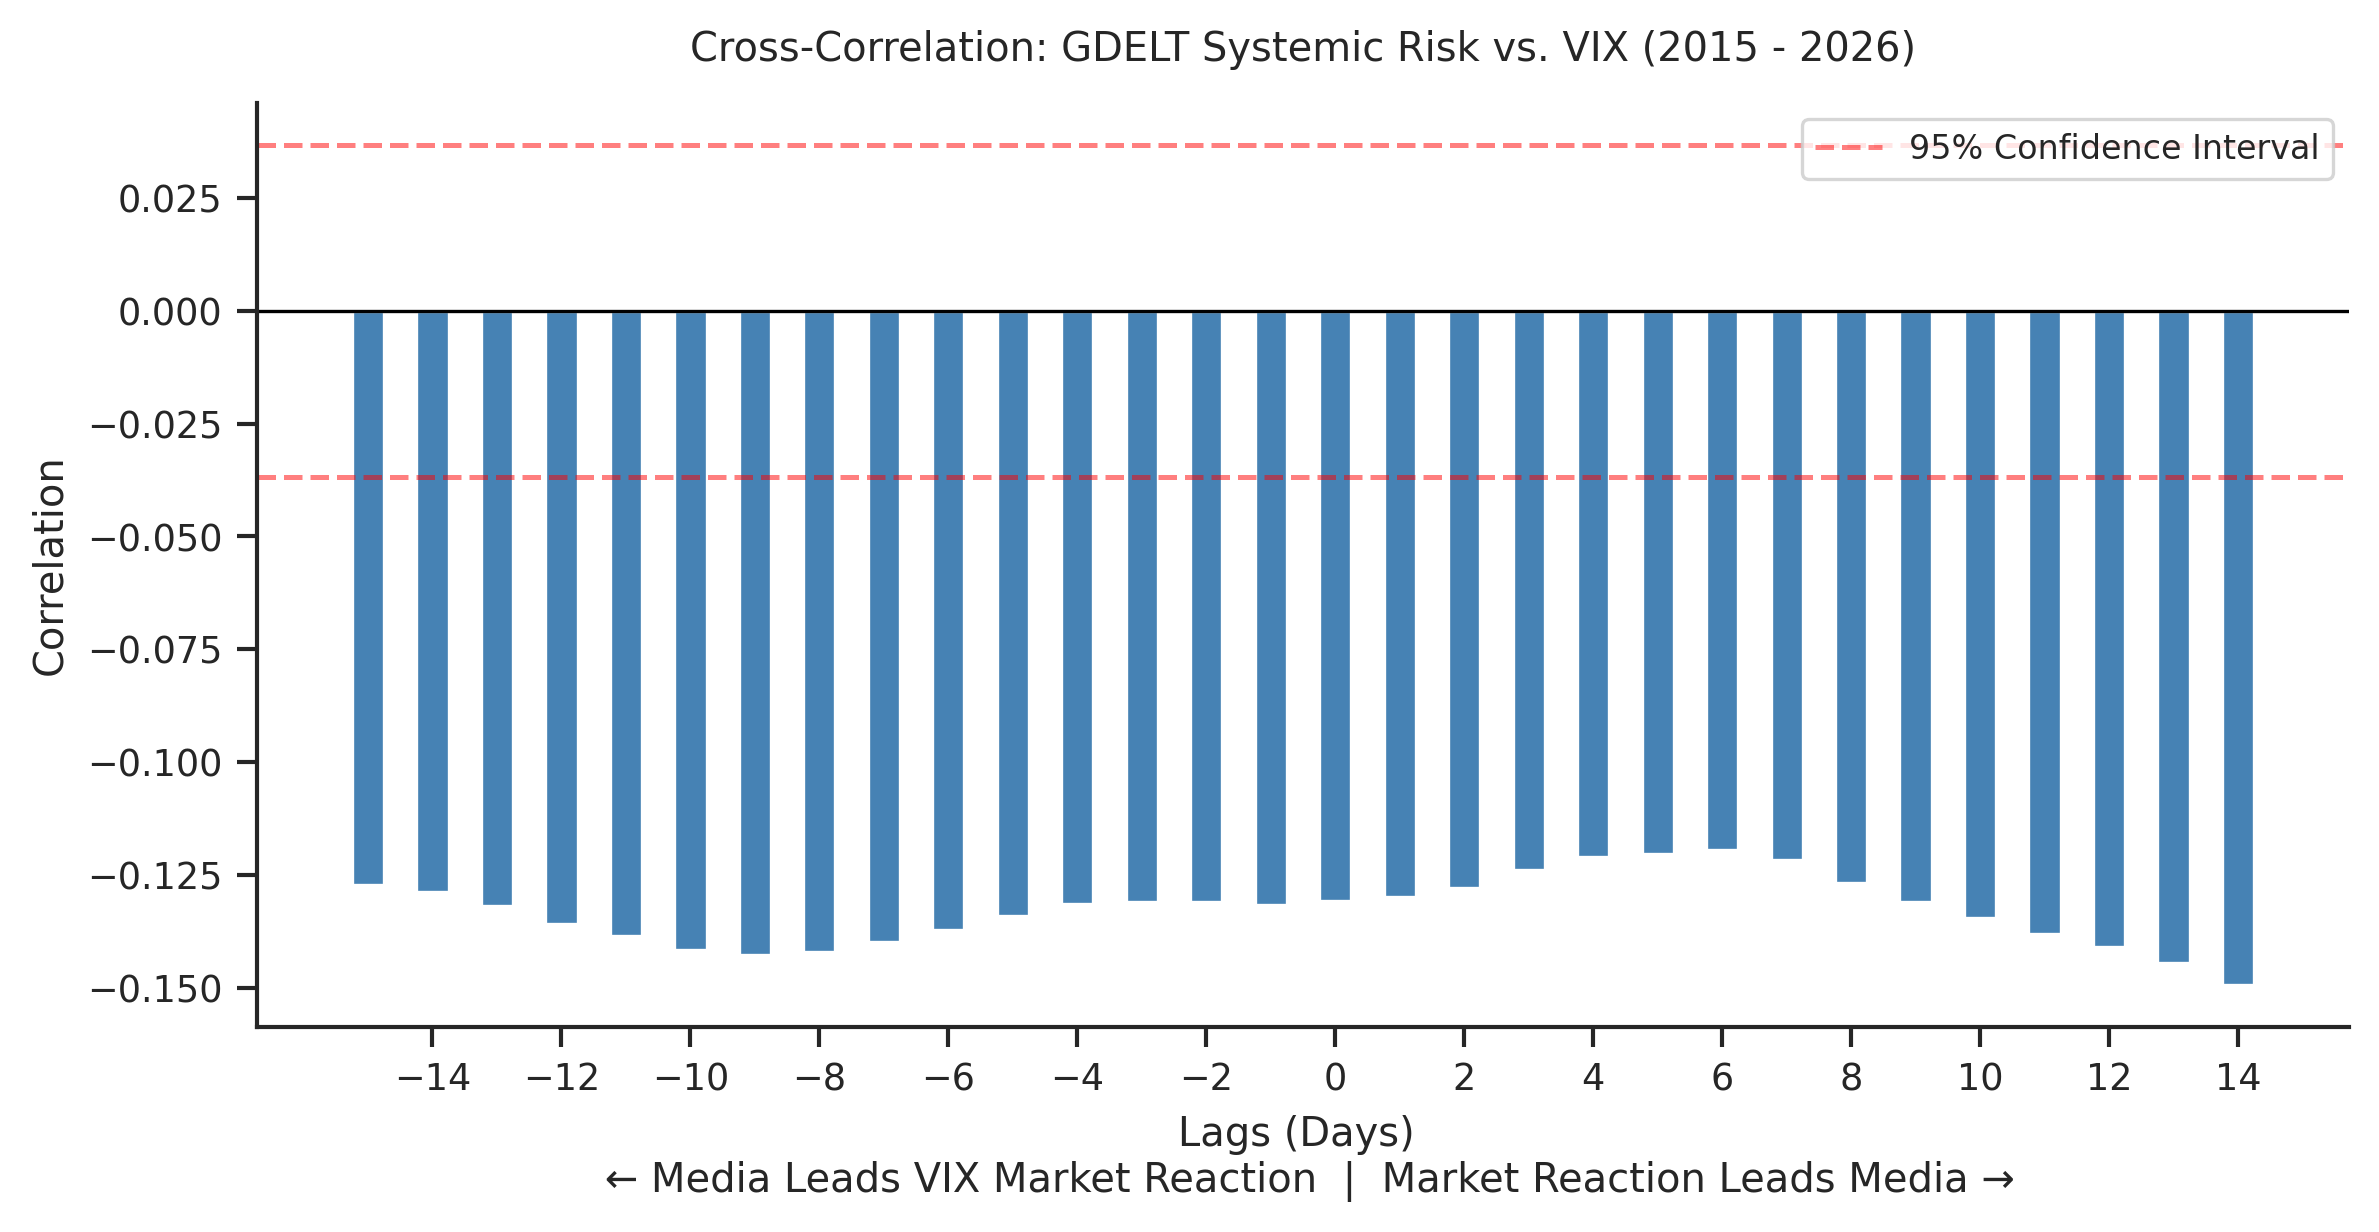


--- Granger Causality Test Results (Full Sample) ---

1. Null Hypothesis: GDELT Systemic Risk does NOT Granger-cause VIX
Lag 1: p-value = 0.4283 
Lag 2: p-value = 0.5995 
Lag 3: p-value = 0.4628 
Lag 4: p-value = 0.4160 
Lag 5: p-value = 0.2242 

2. Null Hypothesis: VIX does NOT Granger-cause GDELT Systemic Risk
Lag 1: p-value = 0.2717 
Lag 2: p-value = 0.2908 
Lag 3: p-value = 0.3793 
Lag 4: p-value = 0.4079 
Lag 5: p-value = 0.3184 


/home/clucas/venvs/gdelt/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/clucas/venvs/gdelt/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [63]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import ccf, grangercausalitytests

# ==========================================
# 1. PREPARE GDELT DATA (FULL SAMPLE)
# ==========================================
df_us = df_geo[df_geo['region_key'] == 'US'].copy()
df_us['period'] = pd.to_datetime(df_us['period'])
df_us = df_us.set_index('period')

# Extract full sample
df_us_full = df_us[['att_weight_finance_systemic_risk']].copy()

# 7-day rolling average to smooth weekend publication drops
df_us_full['GDELT_smoothed'] = df_us_full['att_weight_finance_systemic_risk'].rolling(window=7, min_periods=1).mean()

# ==========================================
# 2. FETCH VIX DATA (FULL SAMPLE)
# ==========================================
start_date = df_us_full.index.min().strftime('%Y-%m-%d')
end_date = df_us_full.index.max().strftime('%Y-%m-%d')
print(f"Fetching VIX data from {start_date} to {end_date}...")

vix_data = yf.download('^VIX', start=start_date, end=end_date)

if isinstance(vix_data.columns, pd.MultiIndex):
    vix_close = vix_data['Close']['^VIX']
else:
    vix_close = vix_data['Close']
    
df_vix = pd.DataFrame({'VIX': vix_close})
df_vix.index = pd.to_datetime(df_vix.index).tz_localize(None)

# ==========================================
# 3. MERGE AND STANDARDIZE
# ==========================================
df_stat = df_vix.join(df_us_full, how='inner').dropna()

# Z-Scores
df_stat['VIX_Z'] = (df_stat['VIX'] - df_stat['VIX'].mean()) / df_stat['VIX'].std()
df_stat['GDELT_Z'] = (df_stat['GDELT_smoothed'] - df_stat['GDELT_smoothed'].mean()) / df_stat['GDELT_smoothed'].std()

# ==========================================
# 4. CROSS-CORRELATION FUNCTION (CCF)
# ==========================================
# Calculate CCF: VIX vs lagged/leaded GDELT
lags_forward = ccf(df_stat['VIX_Z'], df_stat['GDELT_Z'], adjusted=False)[:15]  # GDELT lags VIX
lags_backward = ccf(df_stat['GDELT_Z'], df_stat['VIX_Z'], adjusted=False)[1:16] # GDELT leads VIX

# Combine into a single array from -15 to +14
ccf_values = np.concatenate((lags_backward[::-1], lags_forward))
lags = np.arange(-15, 15)

sns.set_theme(style="ticks", context="paper")
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(lags, ccf_values, color='steelblue', width=0.5)
ax.axhline(0, color='black', linewidth=0.8)

# Significance bounds (approximate 95% confidence interval)
conf_level = 1.96 / np.sqrt(len(df_stat))
ax.axhline(conf_level, color='red', linestyle='--', alpha=0.5, label='95% Confidence Interval')
ax.axhline(-conf_level, color='red', linestyle='--', alpha=0.5)

ax.set_title(f'Cross-Correlation: GDELT Systemic Risk vs. VIX ({start_date[:4]} - {end_date[:4]})', pad=10)
ax.set_xlabel('Lags (Days) \n ← Media Leads VIX Market Reaction  |  Market Reaction Leads Media →')
ax.set_ylabel('Correlation')
ax.set_xticks(np.arange(-14, 15, 2))
ax.legend(loc='upper right', fontsize=8)
sns.despine()

# plt.savefig('./plots/attention_time_series/Fig_CCF_FullSample.pdf', bbox_inches='tight')
plt.show()

# ==========================================
# 5. GRANGER CAUSALITY TESTS
# ==========================================
print("\n--- Granger Causality Test Results (Full Sample) ---")
max_lag = 5

print("\n1. Null Hypothesis: GDELT Systemic Risk does NOT Granger-cause VIX")
gc_res_1 = grangercausalitytests(df_stat[['VIX_Z', 'GDELT_Z']], maxlag=max_lag, verbose=False)
for lag in range(1, max_lag + 1):
    p_val = gc_res_1[lag][0]['ssr_ftest'][1]
    print(f"Lag {lag}: p-value = {p_val:.4f} {'*** Reject Null (GDELT Causes VIX)' if p_val < 0.05 else ''}")

print("\n2. Null Hypothesis: VIX does NOT Granger-cause GDELT Systemic Risk")
gc_res_2 = grangercausalitytests(df_stat[['GDELT_Z', 'VIX_Z']], maxlag=max_lag, verbose=False)
for lag in range(1, max_lag + 1):
    p_val = gc_res_2[lag][0]['ssr_ftest'][1]
    print(f"Lag {lag}: p-value = {p_val:.4f} {'*** Reject Null (VIX Causes GDELT)' if p_val < 0.05 else ''}")

In [64]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests

# 1. Isolate the SVB Crisis Window (Q1 - Q2 2023)
df_us_crisis = df_us.loc['2023-01-01':'2023-06-30', ['att_weight_finance_systemic_risk']].copy()

# Note: NO SMOOTHING THIS TIME. We use raw daily attention.
df_us_crisis['GDELT_raw'] = df_us_crisis['att_weight_finance_systemic_risk']

# 2. Get VIX for the same window
vix_crisis = df_vix.loc['2023-01-01':'2023-06-30'].copy()

# 3. Merge and drop NaNs
df_crisis_stat = vix_crisis.join(df_us_crisis, how='inner').dropna()

# 4. Compute First Differences (to ensure stationarity for Granger tests)
# Financial time series often need differencing to be stationary
df_crisis_stat['VIX_diff'] = df_crisis_stat['VIX'].diff()
df_crisis_stat['GDELT_diff'] = df_crisis_stat['GDELT_raw'].diff()
df_crisis_stat = df_crisis_stat.dropna()

print("--- Granger Causality: SVB Banking Crisis (Unsmoothed, Differenced) ---")
max_lag = 5

print("\n1. Null: GDELT Systemic Risk does NOT Granger-cause VIX")
# Note: verbose argument removed to fix the warning
gc_res_1 = grangercausalitytests(df_crisis_stat[['VIX_diff', 'GDELT_diff']], maxlag=max_lag)

print("\n2. Null: VIX does NOT Granger-cause GDELT Systemic Risk")
gc_res_2 = grangercausalitytests(df_crisis_stat[['GDELT_diff', 'VIX_diff']], maxlag=max_lag)

--- Granger Causality: SVB Banking Crisis (Unsmoothed, Differenced) ---

1. Null: GDELT Systemic Risk does NOT Granger-cause VIX

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=2.7921  , p=0.0974  , df_denom=119, df_num=1
ssr based chi2 test:   chi2=2.8624  , p=0.0907  , df=1
likelihood ratio test: chi2=2.8294  , p=0.0926  , df=1
parameter F test:         F=2.7921  , p=0.0974  , df_denom=119, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.7312  , p=0.1816  , df_denom=116, df_num=2
ssr based chi2 test:   chi2=3.6117  , p=0.1643  , df=2
likelihood ratio test: chi2=3.5588  , p=0.1687  , df=2
parameter F test:         F=1.7312  , p=0.1816  , df_denom=116, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.3517  , p=0.2613  , df_denom=113, df_num=3
ssr based chi2 test:   chi2=4.3064  , p=0.2302  , df=3
likelihood ratio test: chi2=4.2309  , p=0.2376  , df=3
parameter F test:         F=1.3517  , 